In [19]:
%matplotlib inline
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datascience import Table

In [20]:
# Download all data (2000-present for long-term trends)
tickers = {
    'DX-Y.NYB': 'DXY',           # Dollar Index
    'GC=F': 'Gold',              # Gold Futures
    'EURUSD=X': 'EUR/USD',       # Euro vs Dollar
    'GBPUSD=X': 'GBP/USD',       # Pound vs Dollar
    'JPYUSD=X': 'JPY/USD',       # Yen vs Dollar
    'SPY': 'S&P500',             # Equities
    'TLT': 'Bonds',              # 20+ Year Treasury Bonds
    'SLV': 'Silver'              # Silver (another metal)
}

# Download each dataset
data = {}
for ticker, name in tickers.items():
    df = yf.download(ticker, start='2000-01-01', end='2024-12-31')
    df.columns = df.columns.get_level_values(0)
    df_reset = df.reset_index()
    data[name] = Table.from_df(df_reset)
    print(f"Downloaded {name}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Downloaded DXY
Downloaded Gold
Downloaded EUR/USD
Downloaded GBP/USD
Downloaded JPY/USD
Downloaded S&P500


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded Bonds
Downloaded Silver


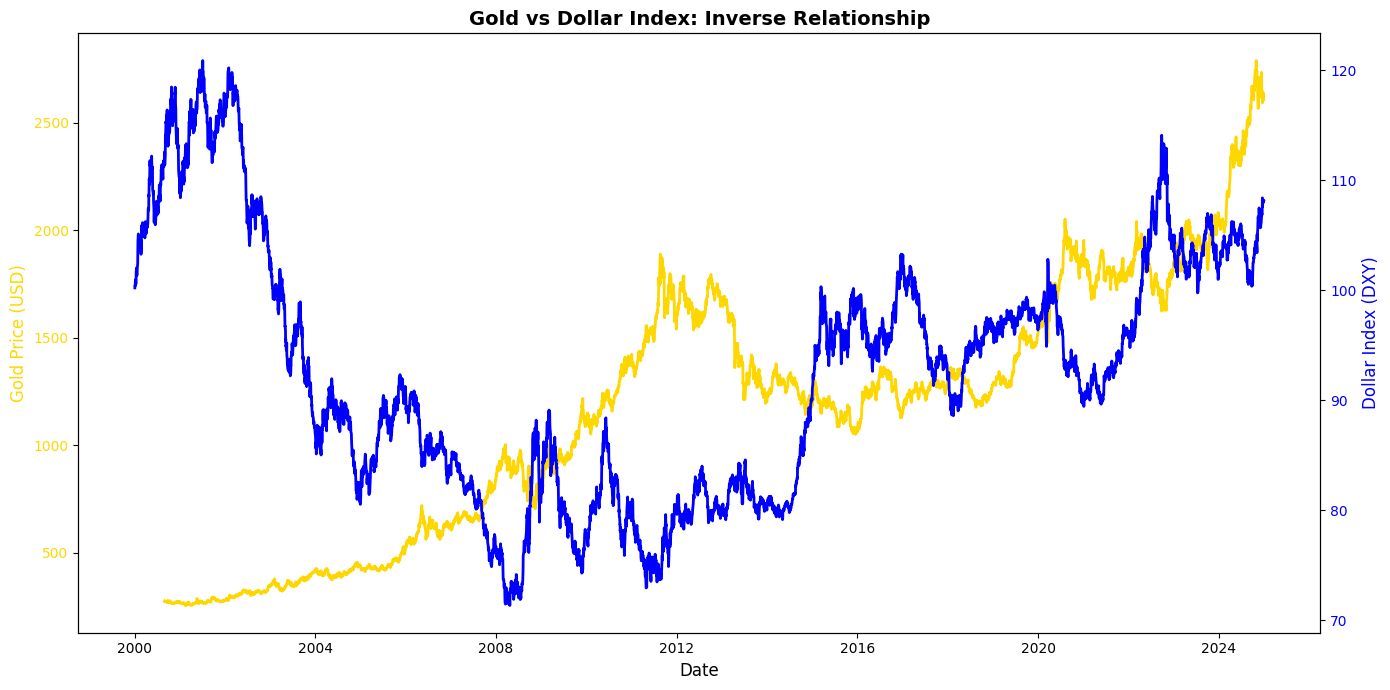

<Figure size 1400x800 with 0 Axes>

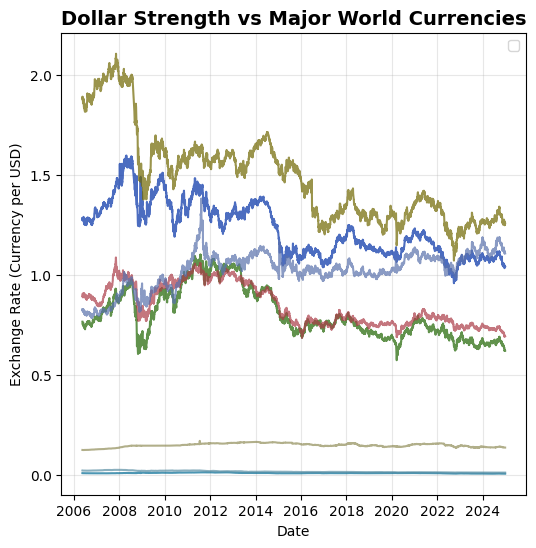

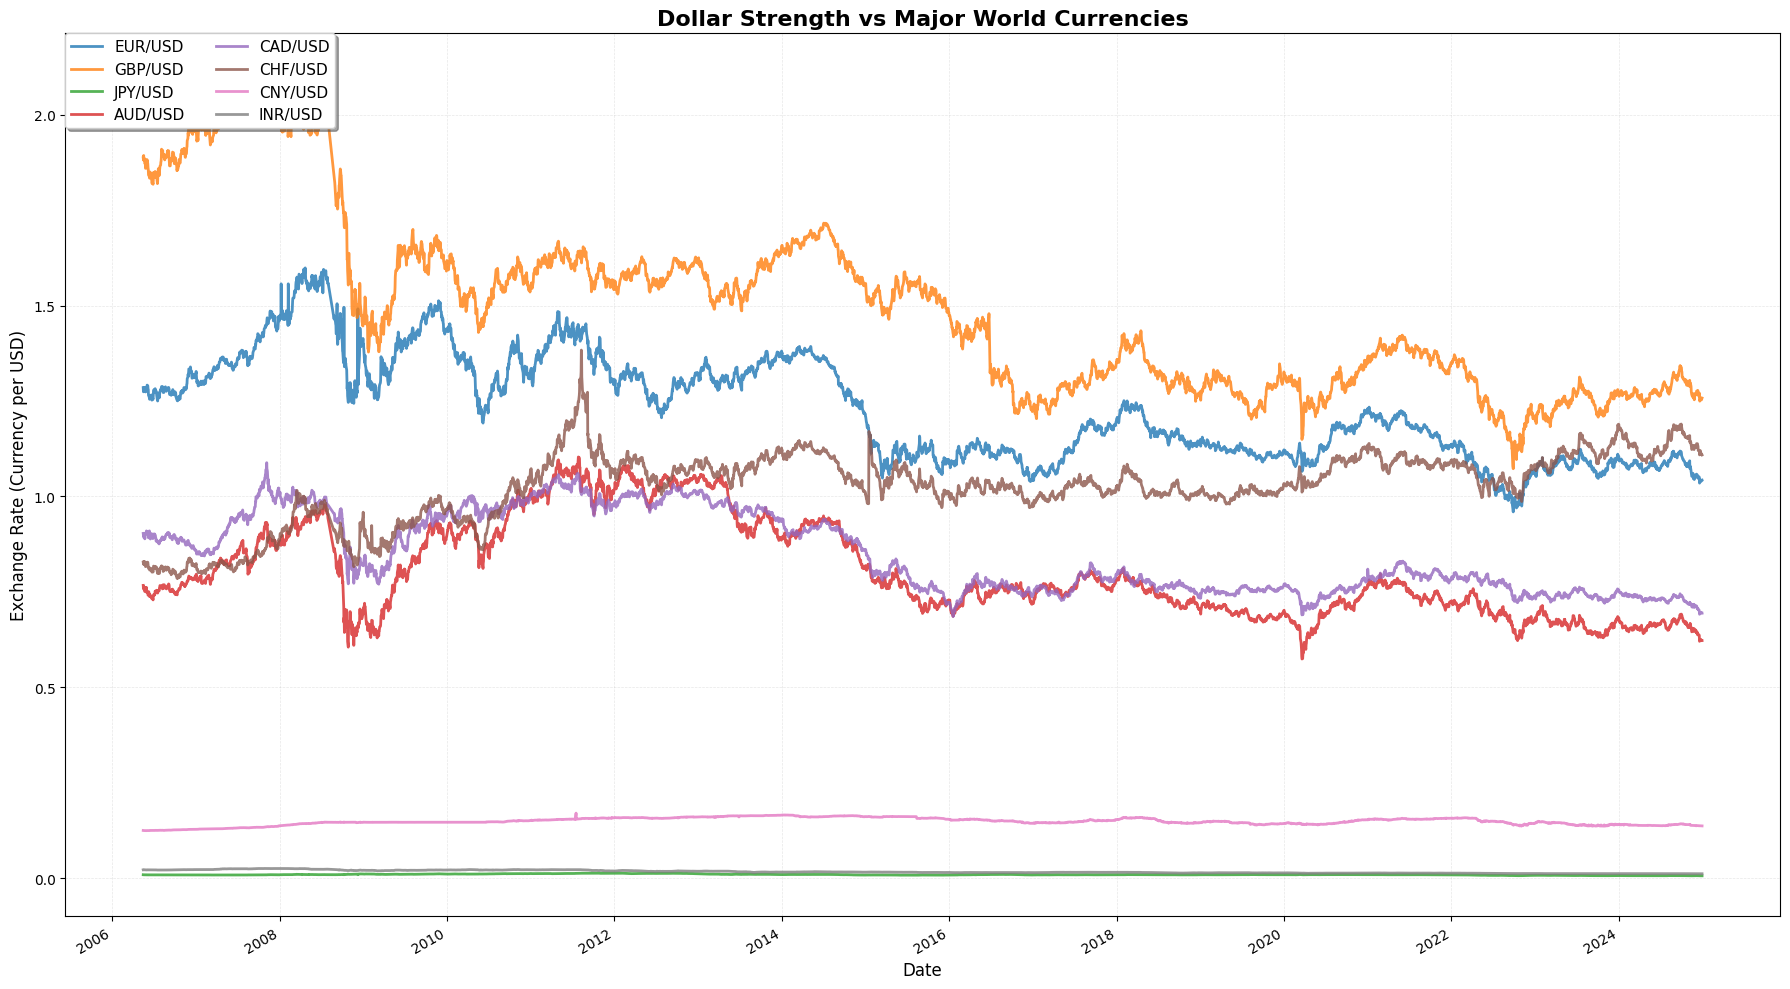

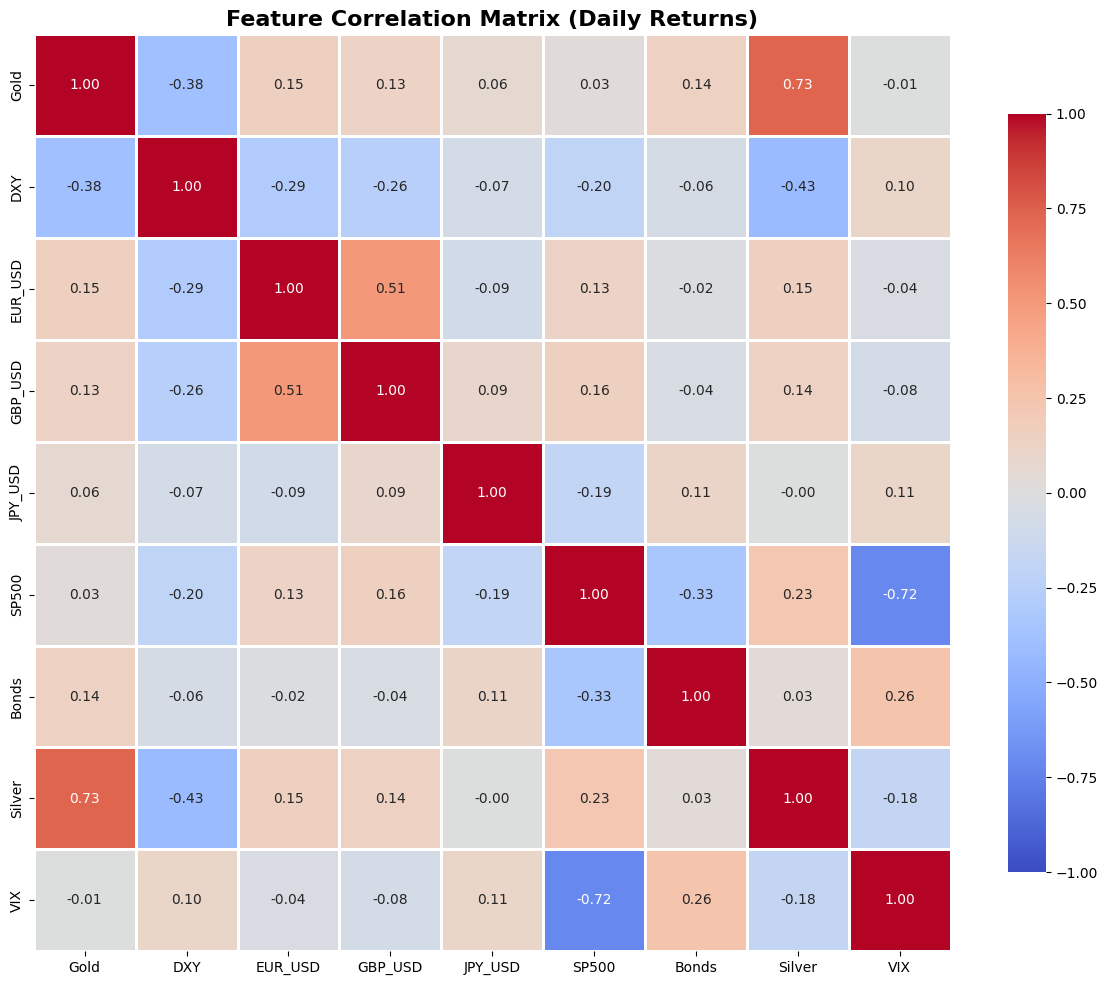

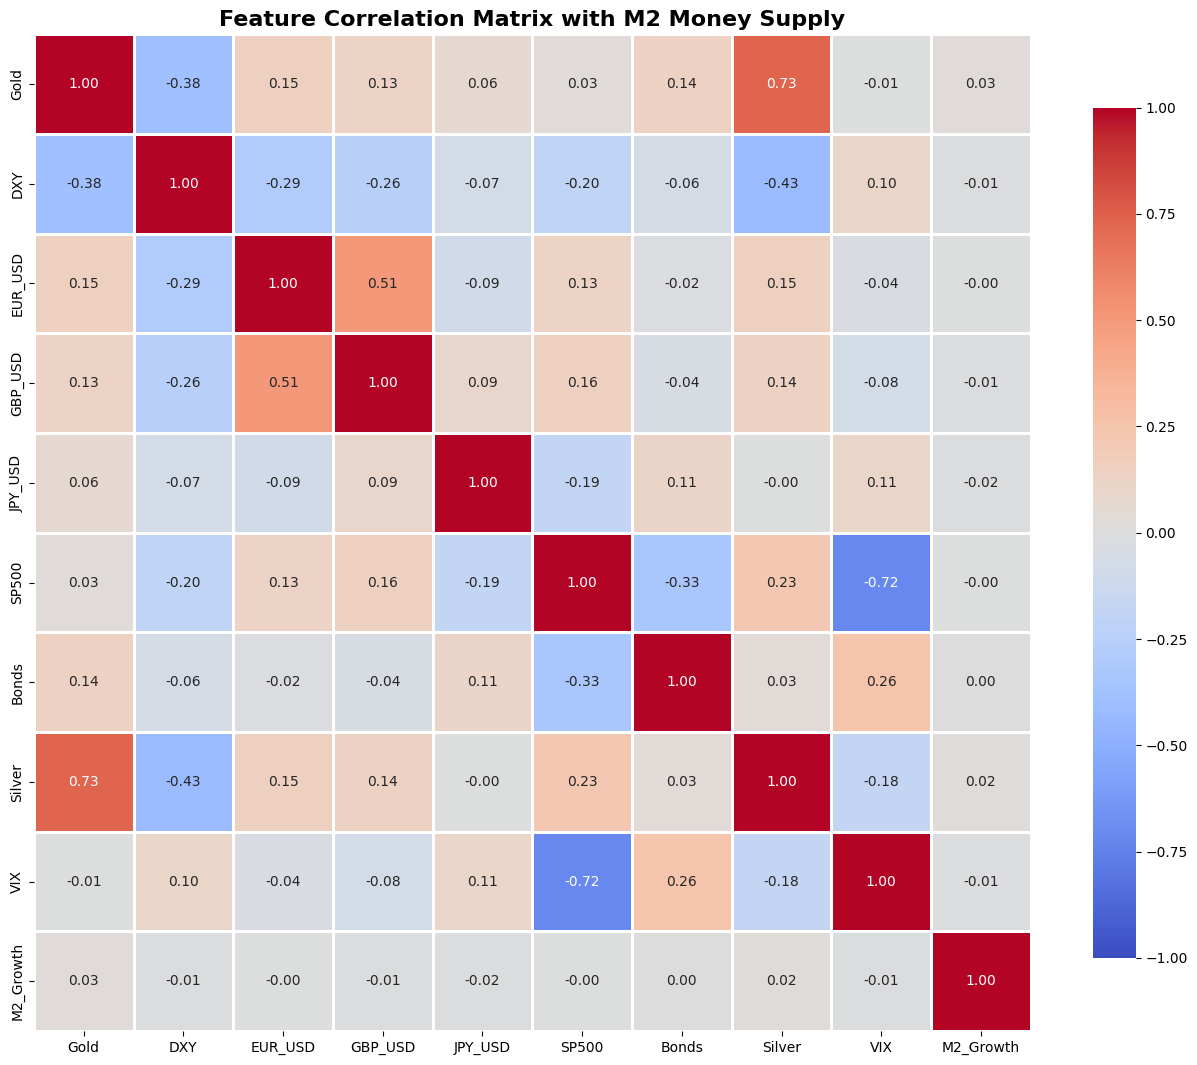

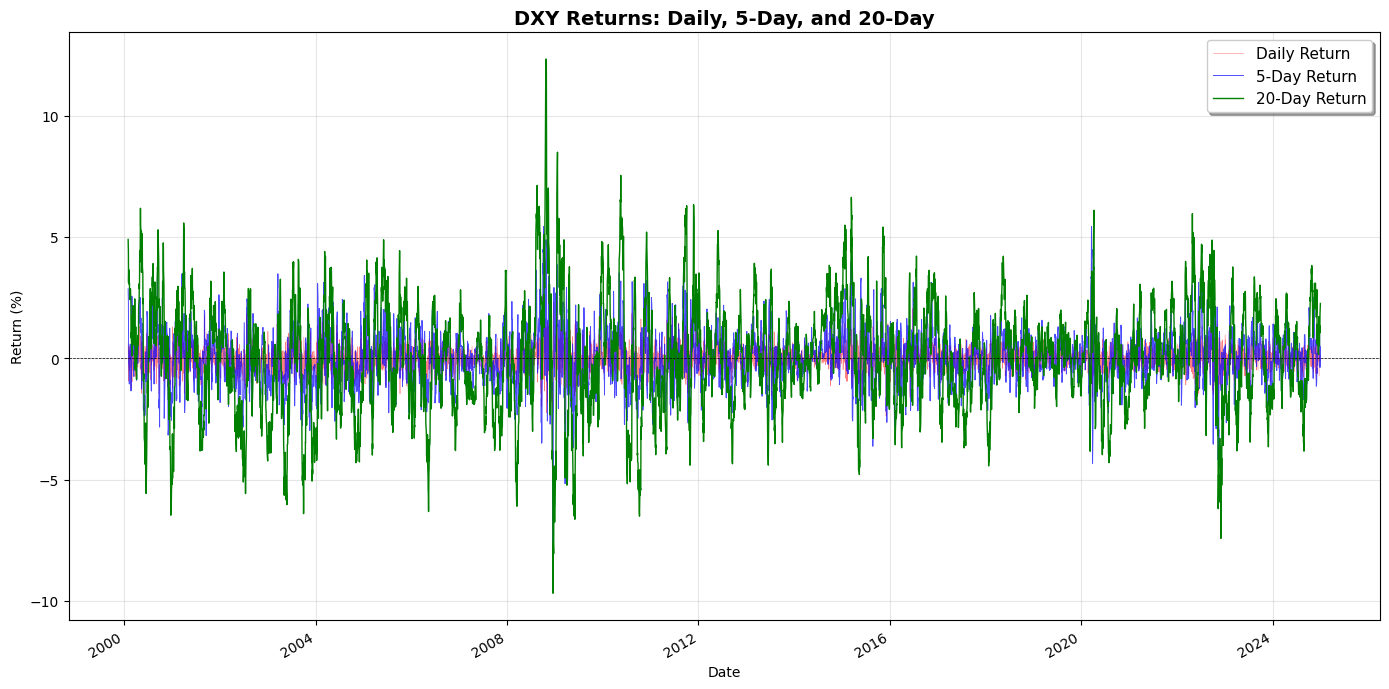

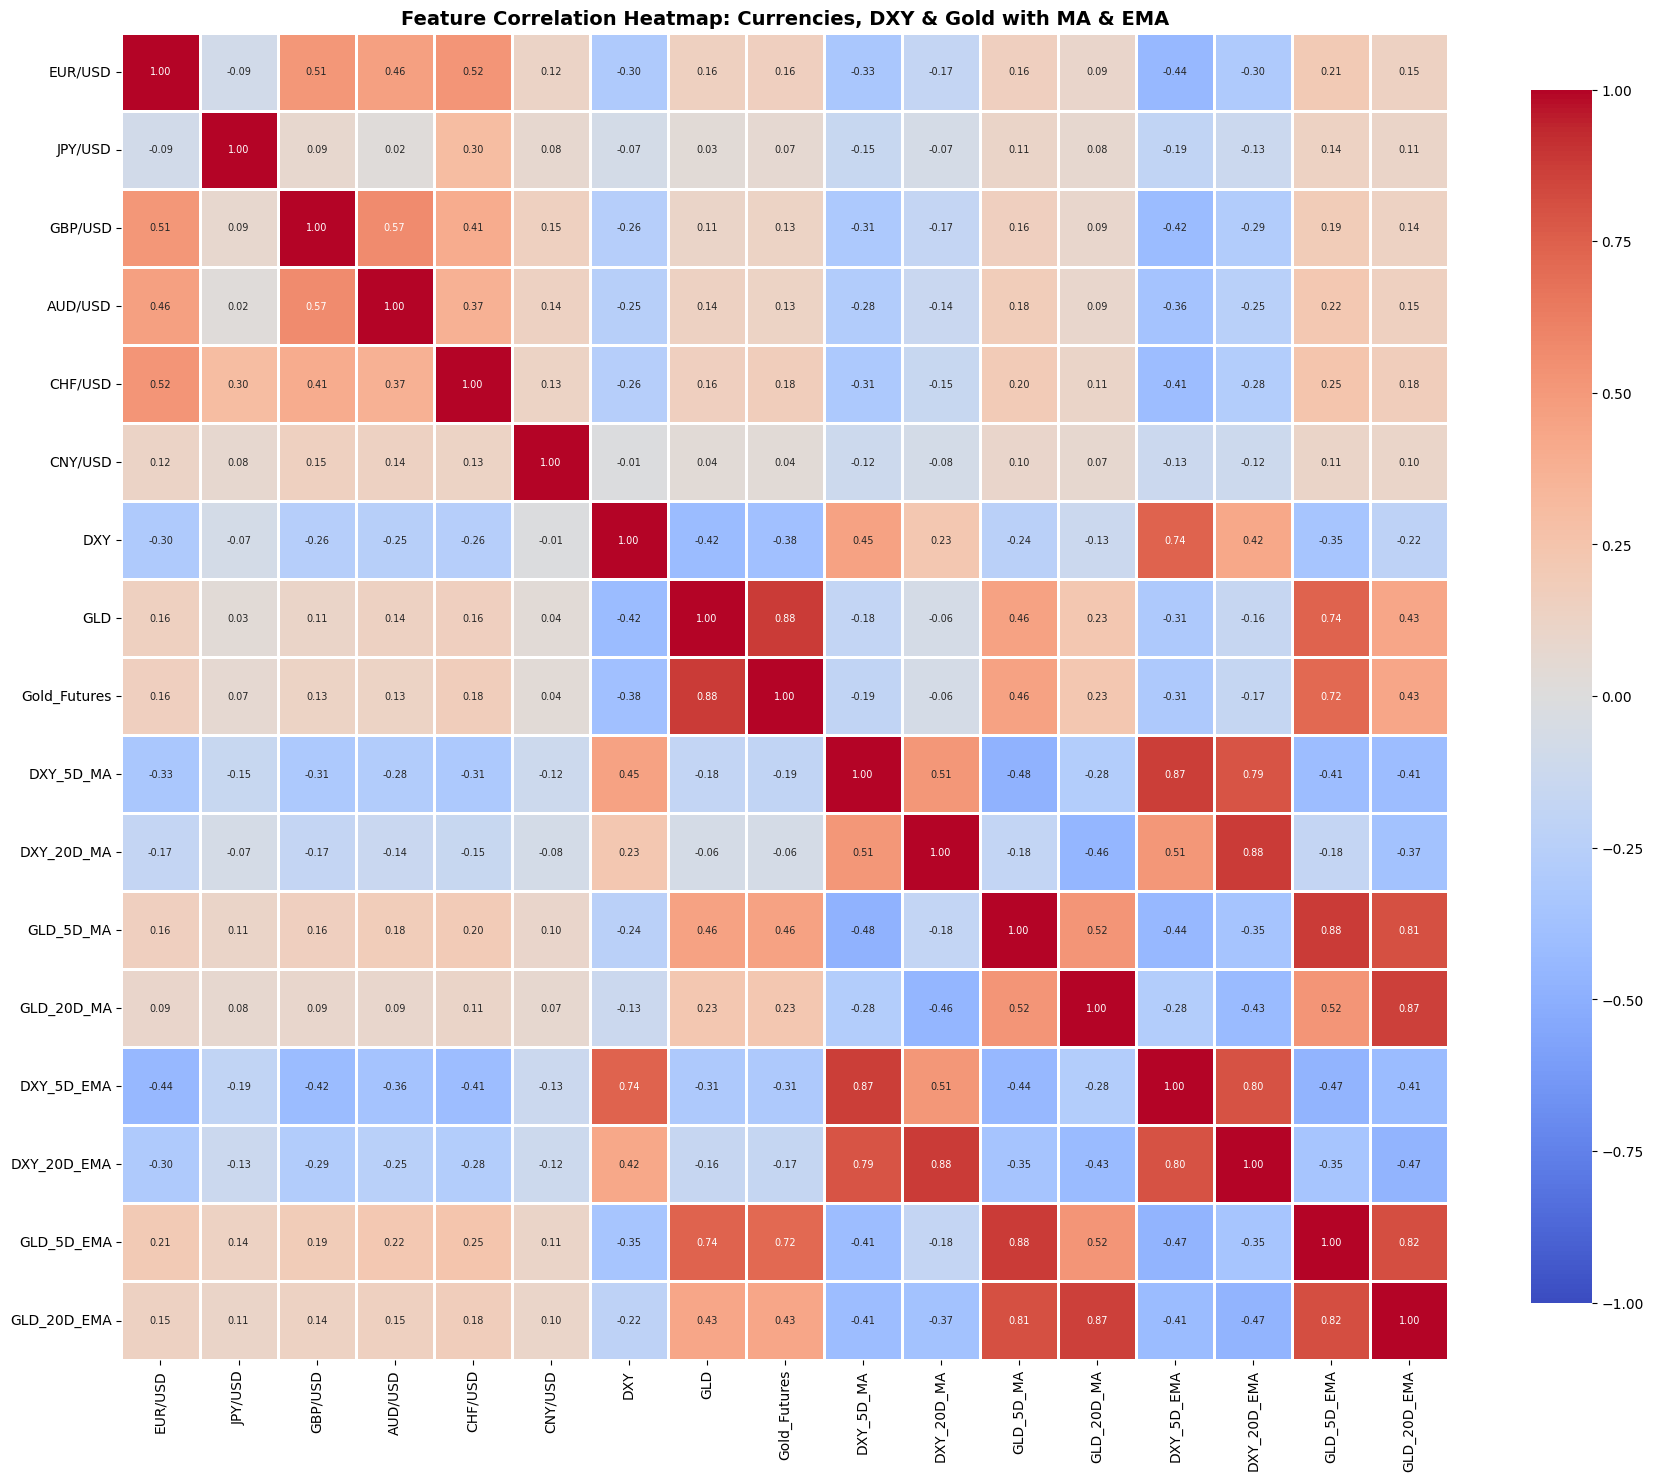

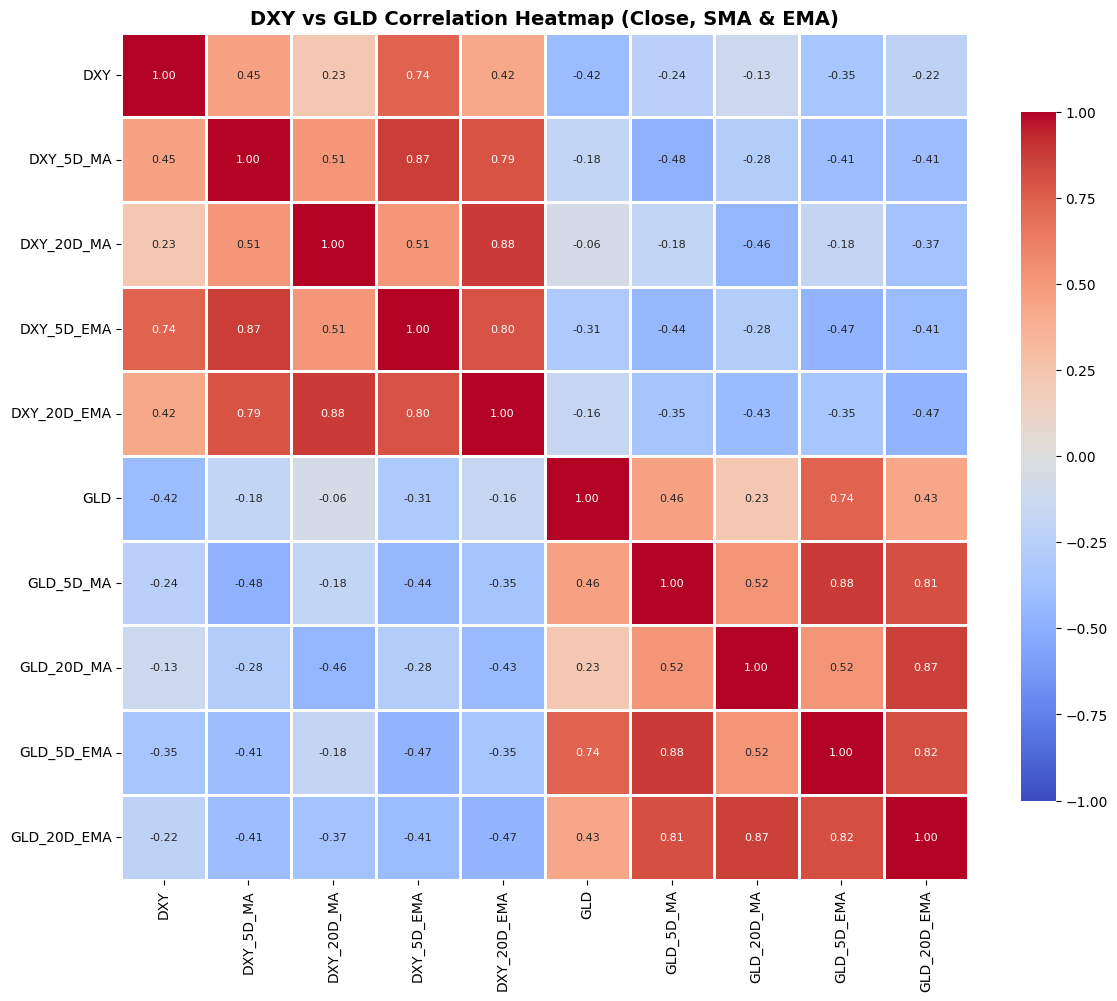

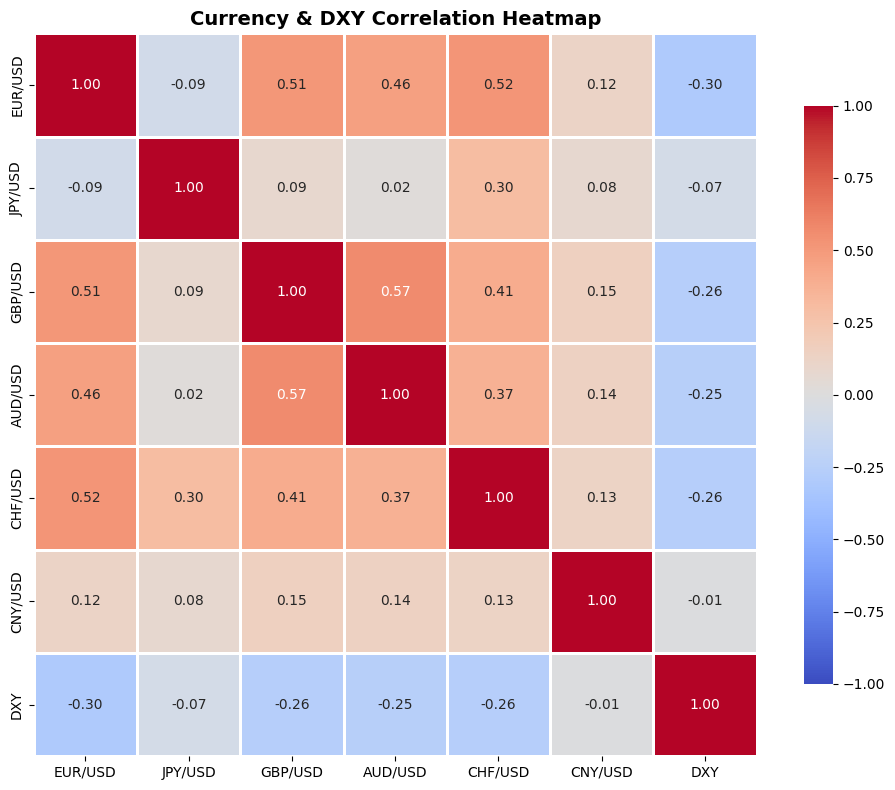

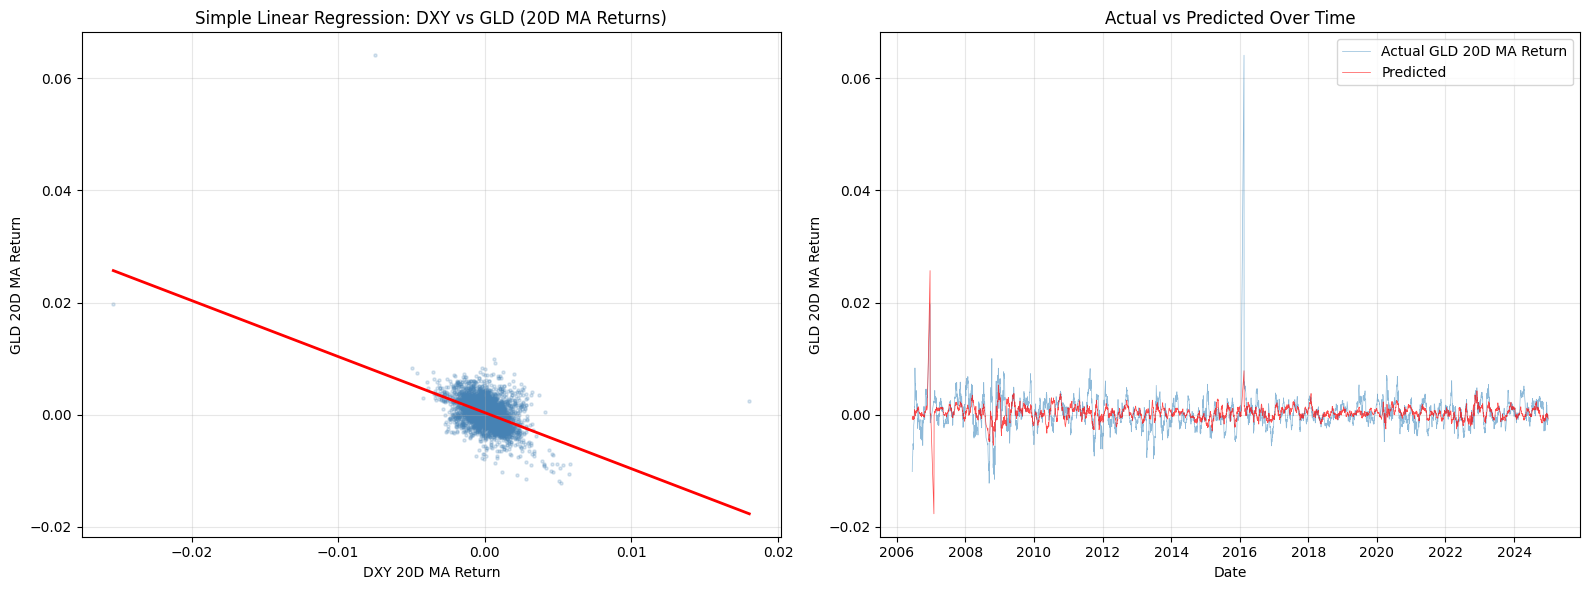

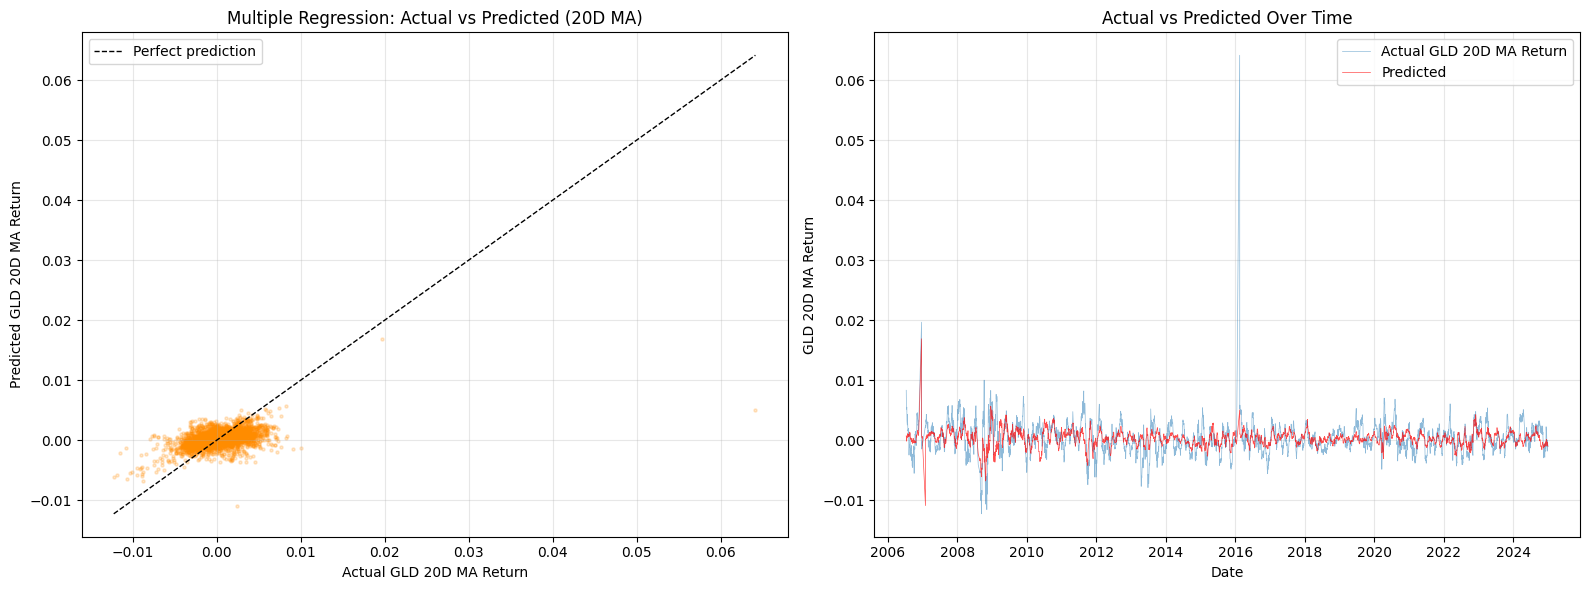

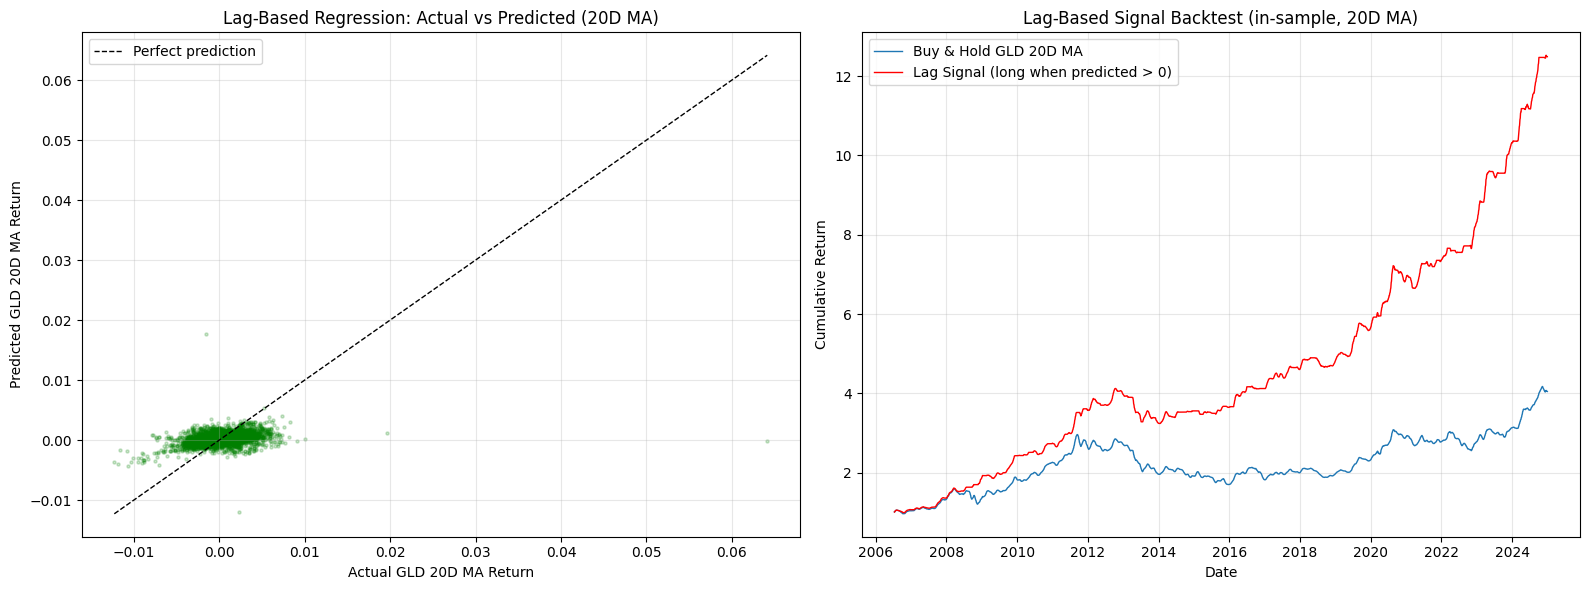

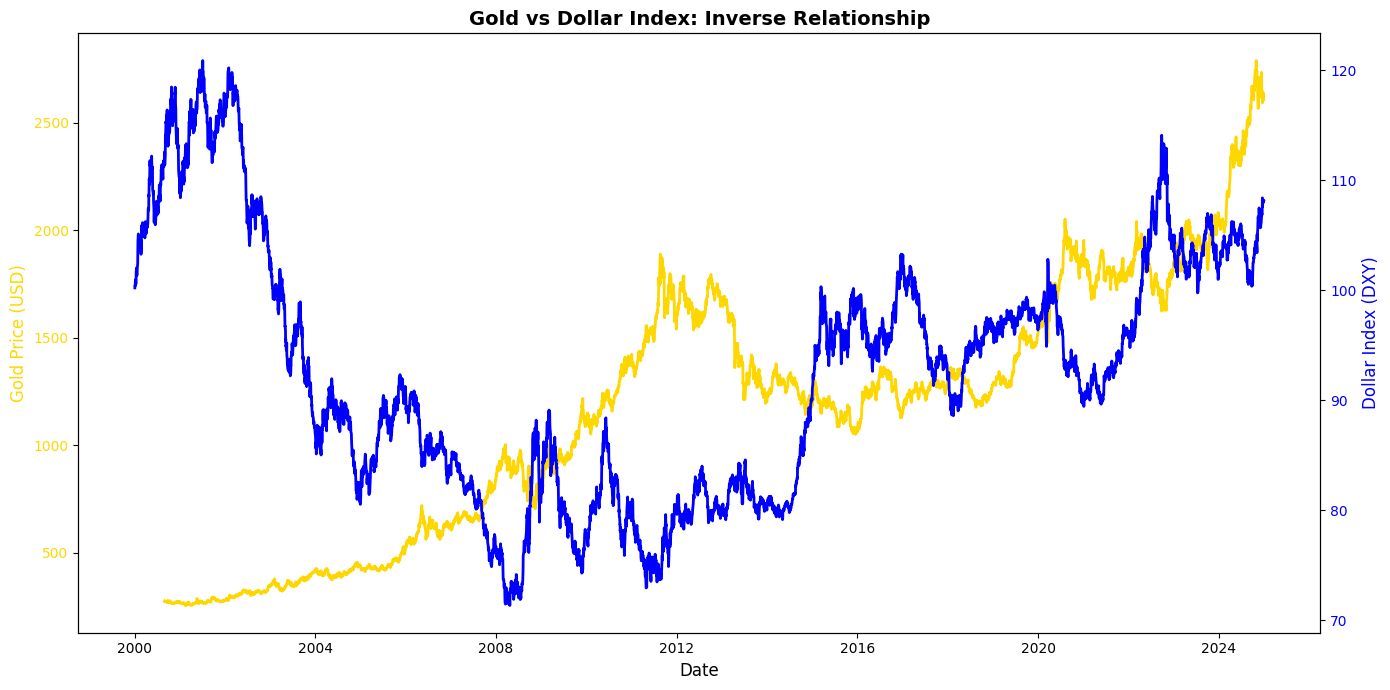

In [21]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Gold on left axis
ax1.plot(data['Gold'].column('Date'), data['Gold'].column('Close'), 'gold', linewidth=2, label='Gold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Gold Price (USD)', color='gold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='gold')

# DXY on right axis (inverted to show inverse relationship)
ax2 = ax1.twinx()
ax2.plot(data['DXY'].column('Date'), data['DXY'].column('Close'), 'blue', linewidth=2, label='Dollar Index')
ax2.set_ylabel('Dollar Index (DXY)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Gold vs Dollar Index: Inverse Relationship', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Downloaded EUR/USD
Downloaded GBP/USD
Downloaded JPY/USD
Downloaded AUD/USD
Downloaded CAD/USD
Downloaded CHF/USD


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Downloaded CNY/USD
Downloaded INR/USD


/var/folders/wg/c0dxnsv579g_t07vnd6vvfkc0000gn/T/ipykernel_38157/2563050532.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


<Figure size 1400x800 with 0 Axes>

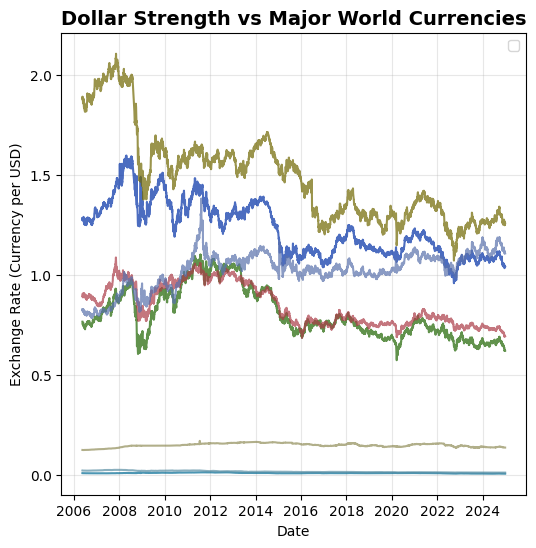

In [22]:
# Download additional currencies (including Rupee)
currencies_tickers = {
    'EURUSD=X': 'EUR/USD',
    'GBPUSD=X': 'GBP/USD', 
    'JPYUSD=X': 'JPY/USD',
    'AUDUSD=X': 'AUD/USD',  # Australian Dollar
    'CADUSD=X': 'CAD/USD',  # Canadian Dollar
    'CHFUSD=X': 'CHF/USD',  # Swiss Franc
    'CNYUSD=X': 'CNY/USD',  # Chinese Yuan
    'INRUSD=X': 'INR/USD'   # Indian Rupee
}

# Download and prepare each currency
currency_data = {}
for ticker, name in currencies_tickers.items():
    df = yf.download(ticker, start='2000-01-01', end='2024-12-31')
    df.columns = df.columns.get_level_values(0)
    df_reset = df.reset_index()
    currency_data[name] = Table.from_df(df_reset)
    print(f"Downloaded {name}")

# Combine all currencies into one table
eur_clean = currency_data['EUR/USD'].select('Date', 'Close').relabeled('Close', 'EUR/USD')
gbp_clean = currency_data['GBP/USD'].select('Date', 'Close').relabeled('Close', 'GBP/USD')
jpy_clean = currency_data['JPY/USD'].select('Date', 'Close').relabeled('Close', 'JPY/USD')
aud_clean = currency_data['AUD/USD'].select('Date', 'Close').relabeled('Close', 'AUD/USD')
cad_clean = currency_data['CAD/USD'].select('Date', 'Close').relabeled('Close', 'CAD/USD')
chf_clean = currency_data['CHF/USD'].select('Date', 'Close').relabeled('Close', 'CHF/USD')
cny_clean = currency_data['CNY/USD'].select('Date', 'Close').relabeled('Close', 'CNY/USD')
inr_clean = currency_data['INR/USD'].select('Date', 'Close').relabeled('Close', 'INR/USD')

# Join all currencies
currencies = eur_clean.join('Date', gbp_clean, 'Date') \
                      .join('Date', jpy_clean, 'Date') \
                      .join('Date', aud_clean, 'Date') \
                      .join('Date', cad_clean, 'Date') \
                      .join('Date', chf_clean, 'Date') \
                      .join('Date', cny_clean, 'Date') \
                      .join('Date', inr_clean, 'Date')

# Plot all currencies
plt.figure(figsize=(14, 8))
currencies.plot('Date')
plt.title('Dollar Strength vs Major World Currencies', fontsize=14, fontweight='bold')
plt.ylabel('Exchange Rate (Currency per USD)')
plt.xlabel('Date')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

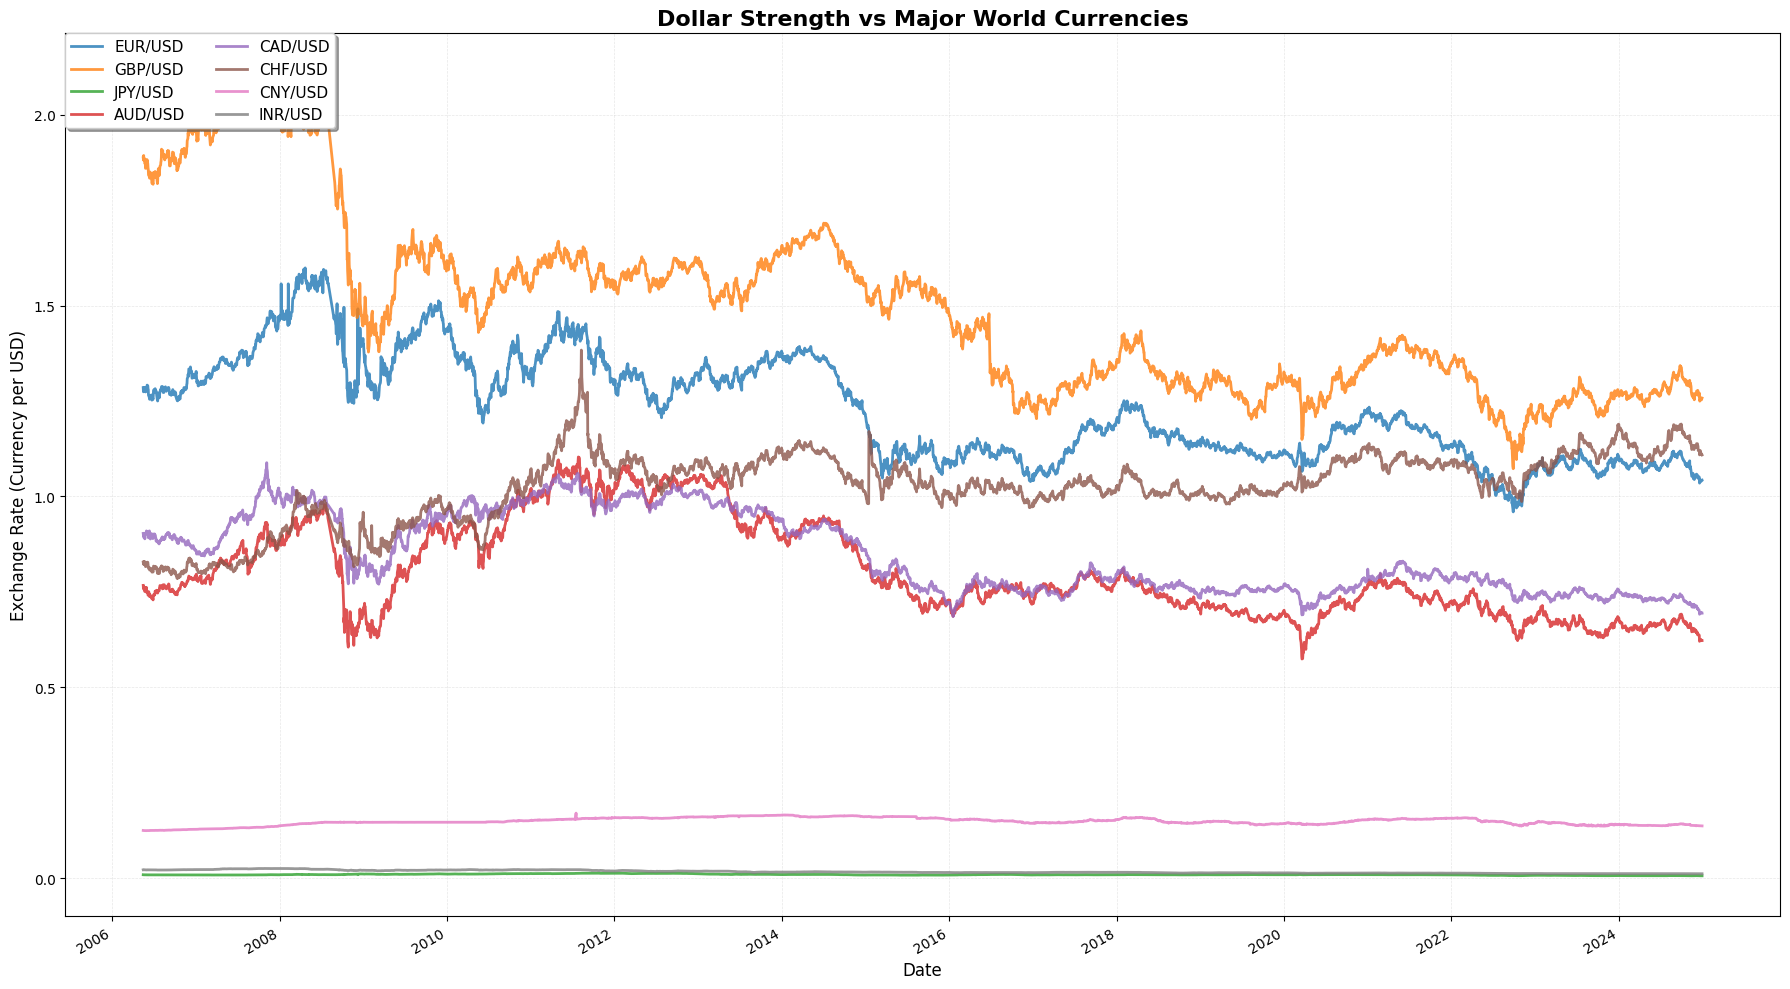

In [23]:
# Plot all currencies with custom styling
fig, ax = plt.subplots(figsize=(18, 10))

# Plot each currency with distinct colors
for i, col in enumerate(currencies.labels[1:]):  # Skip 'Date' column
    ax.plot(currencies.column('Date'), currencies.column(col), 
            label=col, linewidth=2, alpha=0.8)

ax.set_title('Dollar Strength vs Major World Currencies', fontsize=16, fontweight='bold')
ax.set_ylabel('Exchange Rate (Currency per USD)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)

# Better legend positioning
ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True, 
          ncol=2, bbox_to_anchor=(0, 1), borderaxespad=0)

# Spread out x-axis with better formatting
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
fig.autofmt_xdate()

# Add grid
ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Downloaded Gold
Downloaded DXY
Downloaded EUR_USD
Downloaded GBP_USD
Downloaded JPY_USD
Downloaded SP500
Downloaded Bonds


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/var/folders/wg/c0dxnsv579g_t07vnd6vvfkc0000gn/T/ipykernel_38157/2153238148.py:33: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_data = all_data.pct_change().dropna()


Downloaded Silver
Downloaded VIX


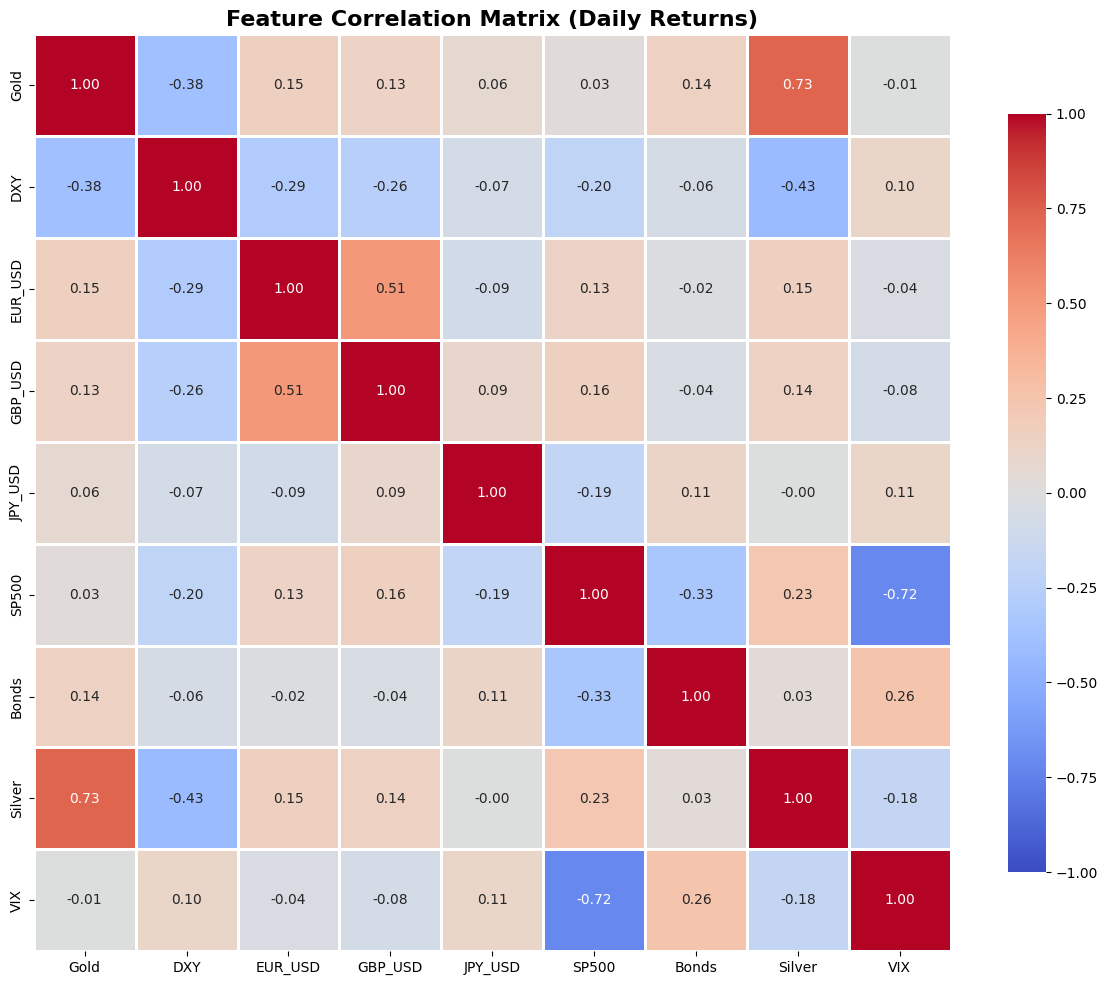


Strongest correlations with Gold:
Gold       1.000000
Silver     0.726664
EUR_USD    0.154259
Bonds      0.141944
GBP_USD    0.126035
JPY_USD    0.063218
SP500      0.025402
VIX       -0.006200
DXY       -0.382992
Name: Gold, dtype: float64


In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download all features
tickers = {
    'GC=F': 'Gold',
    'DX-Y.NYB': 'DXY',
    'EURUSD=X': 'EUR_USD',
    'GBPUSD=X': 'GBP_USD',
    'JPYUSD=X': 'JPY_USD',
    'SPY': 'SP500',
    'TLT': 'Bonds',
    'SLV': 'Silver',
    '^VIX': 'VIX'
}

# Download and combine data
all_data = pd.DataFrame()

for ticker, name in tickers.items():
    df = yf.download(ticker, start='2000-01-01', end='2024-12-31')
    # Get just the Close price
    if 'Close' in df.columns:
        all_data[name] = df['Close']
    else:
        all_data[name] = df['Close'].iloc[:, 0]
    print(f"Downloaded {name}")

# Calculate returns (percent change) - more meaningful than raw prices
returns_data = all_data.pct_change().dropna()

# Calculate correlation matrix
correlation_matrix = returns_data.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            cmap='coolwarm',  # Color scheme
            center=0,  # Center colormap at 0
            square=True,  # Square cells
            linewidths=1,  # Grid lines
            cbar_kws={"shrink": 0.8},
            fmt='.2f',  # 2 decimal places
            vmin=-1, vmax=1)  # Correlation range

plt.title('Feature Correlation Matrix (Daily Returns)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print strongest correlations with Gold
print("\nStrongest correlations with Gold:")
gold_correlations = correlation_matrix['Gold'].sort_values(ascending=False)
print(gold_correlations)

/var/folders/wg/c0dxnsv579g_t07vnd6vvfkc0000gn/T/ipykernel_38157/861731021.py:17: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_data = all_data.pct_change().dropna()


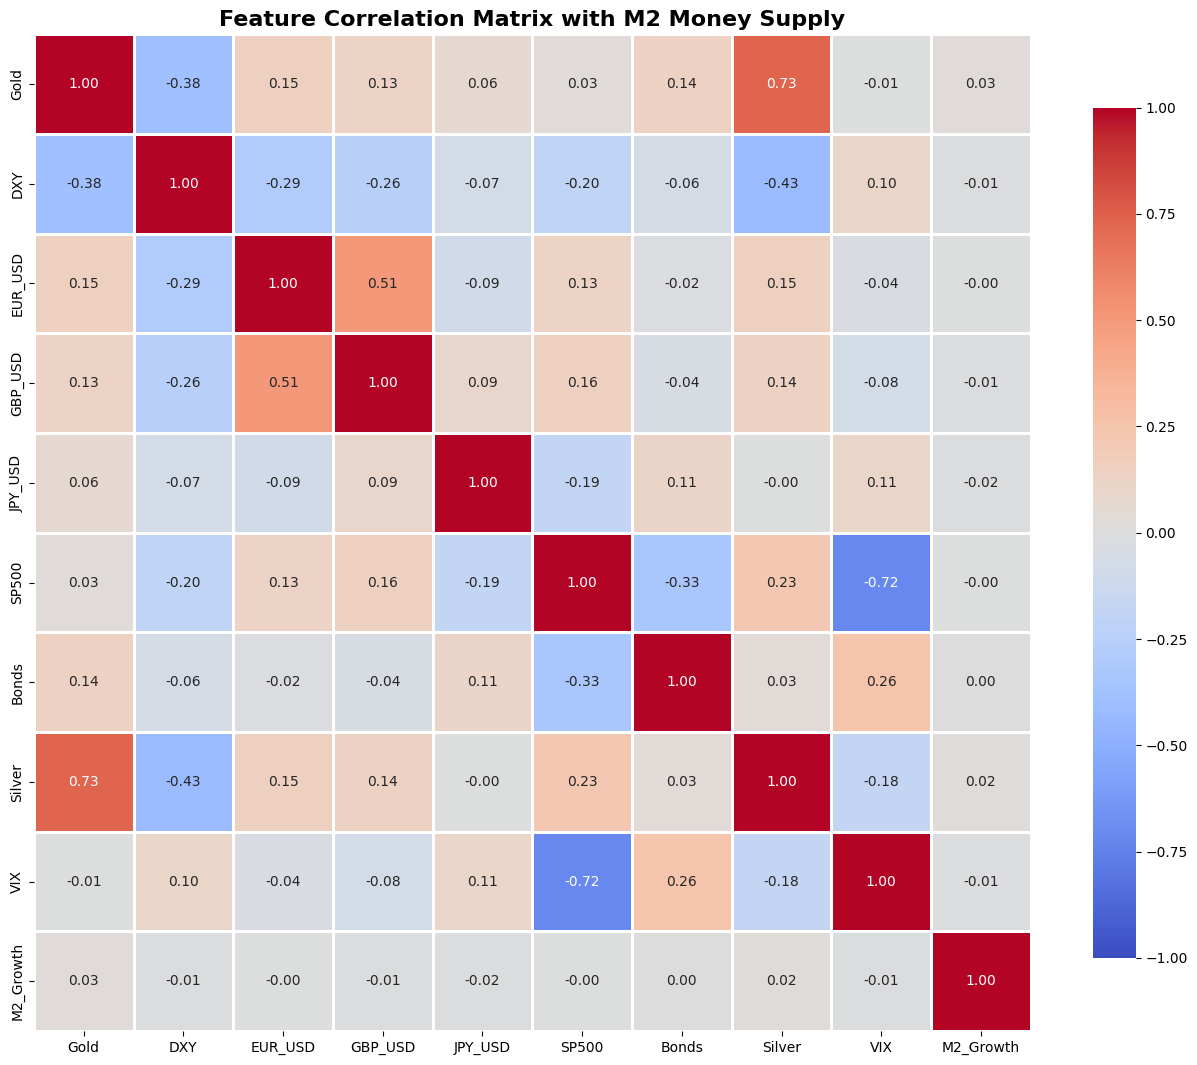

In [25]:
import requests
from io import StringIO

# Get M2 money supply directly from FRED API
url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=M2SL&cosd=2000-01-01'
response = requests.get(url)
m2 = pd.read_csv(StringIO(response.text), parse_dates=['observation_date'], index_col='observation_date')
m2_monthly = m2.resample('D').ffill()  # Convert to daily (forward fill)

# Calculate M2 growth rate (year-over-year)
m2_growth = m2_monthly.pct_change(periods=252)  # ~252 trading days = 1 year

# Add to your dataframe
all_data['M2_Growth'] = m2_growth

# Recalculate correlation
returns_data = all_data.pct_change().dropna()
correlation_matrix = returns_data.corr()

# Recreate heatmap with M2
plt.figure(figsize=(13, 11))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            fmt='.2f',
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix with M2 Money Supply', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Download 6 currency pairs + DXY from Yahoo Finance
currency_tickers = {
    'EURUSD=X': 'EUR/USD',
    'JPYUSD=X': 'JPY/USD',
    'GBPUSD=X': 'GBP/USD',
    'AUDUSD=X': 'AUD/USD',
    'CHFUSD=X': 'CHF/USD',
    'CNYUSD=X': 'CNY/USD',
    'DX-Y.NYB': 'DXY',
}

currency_df = pd.DataFrame()
for ticker, name in currency_tickers.items():
    df = yf.download(ticker, start='2000-01-01', end='2024-12-31')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    currency_df[name] = df['Close']
    print(f"Downloaded {name}: {len(df)} rows")

# Inner join on dates — only keep days where ALL pairs have data
currency_df = currency_df.dropna(how='any')

# Forward-fill then back-fill any remaining gaps, then drop as safety net
currency_df = currency_df.ffill().bfill().dropna()

print(f"\nFinal shape: {currency_df.shape}")
print(f"\nMissing values per column:\n{currency_df.isnull().sum()}")
print(f"\nDate range: {currency_df.index.min()} to {currency_df.index.max()}")
currency_df.head(10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded EUR/USD: 5472 rows
Downloaded JPY/USD: 6492 rows
Downloaded GBP/USD: 5484 rows
Downloaded AUD/USD: 4848 rows
Downloaded CHF/USD: 5538 rows
Downloaded CNY/USD: 5874 rows
Downloaded DXY: 6315 rows

Final shape: (4655, 7)

Missing values per column:
EUR/USD    0
JPY/USD    0
GBP/USD    0
AUD/USD    0
CHF/USD    0
CNY/USD    0
DXY        0
dtype: int64

Date range: 2006-05-16 00:00:00 to 2024-12-30 00:00:00


,EUR/USD,JPY/USD,GBP/USD,AUD/USD,CHF/USD,CNY/USD,DXY
Date,,,,,,,
2006-05-16,1.285000,0.009111,1.887398,0.767106,0.827952,0.125109,84.169998
2006-05-17,1.274194,0.009016,1.882495,0.759417,0.823384,0.125141,84.849998
2006-05-18,1.285099,0.009017,1.893294,0.764000,0.829875,0.124994,84.510002
2006-05-19,1.276699,0.008956,1.880017,0.757174,0.821355,0.124844,84.879997
2006-05-22,1.285298,0.008972,1.885085,0.753409,0.829669,0.124751,84.349998
2006-05-23,1.278298,0.008917,1.877088,0.750976,0.825082,0.124844,84.349998
2006-05-24,1.277400,0.008870,1.871293,0.753125,0.822233,0.124844,84.949997
2006-05-25,1.281000,0.008948,1.875610,0.760919,0.822166,0.124844,84.650002
2006-05-26,1.273902,0.008877,1.859704,0.758093,0.816326,0.124766,85.260002


In [27]:
# Download DXY and compute daily, 5-day, and 20-day returns
dxy_raw = yf.download('DX-Y.NYB', start='2000-01-01', end='2024-12-31')
if isinstance(dxy_raw.columns, pd.MultiIndex):
    dxy_raw.columns = dxy_raw.columns.get_level_values(0)

dxy_returns = pd.DataFrame()
dxy_returns['DXY_Close'] = dxy_raw['Close']
dxy_returns['Daily_Return'] = dxy_raw['Close'].pct_change(periods=1)
dxy_returns['5D_Return'] = dxy_raw['Close'].pct_change(periods=5)
dxy_returns['20D_Return'] = dxy_raw['Close'].pct_change(periods=20)

# Drop rows with NaN (first 20 rows won't have 20-day return)
dxy_returns = dxy_returns.dropna()

print(f"Shape: {dxy_returns.shape}")
print(f"Missing values:\n{dxy_returns.isnull().sum()}")
print(f"Date range: {dxy_returns.index.min()} to {dxy_returns.index.max()}\n")
dxy_returns.head(10)

[*********************100%***********************]  1 of 1 completed

Shape: (6295, 4)
Missing values:
DXY_Close       0
Daily_Return    0
5D_Return       0
20D_Return      0
dtype: int64
Date range: 2000-01-31 00:00:00 to 2024-12-30 00:00:00



,DXY_Close,Daily_Return,5D_Return,20D_Return
Date,,,,
2000-01-31,105.129997,0.006221,0.028669,0.048992
2000-02-01,104.919998,-0.001998,0.024509,0.044916
2000-02-02,104.790001,-0.001239,0.022940,0.043933
2000-02-03,103.800003,-0.009447,0.006106,0.031297
2000-02-04,104.290001,0.004721,-0.001819,0.034623
2000-02-07,104.639999,0.003356,-0.004661,0.036142
2000-02-08,104.220001,-0.004014,-0.006672,0.036396
2000-02-09,103.680000,-0.005181,-0.010593,0.030411
2000-02-10,104.129997,0.004340,0.003179,0.030990


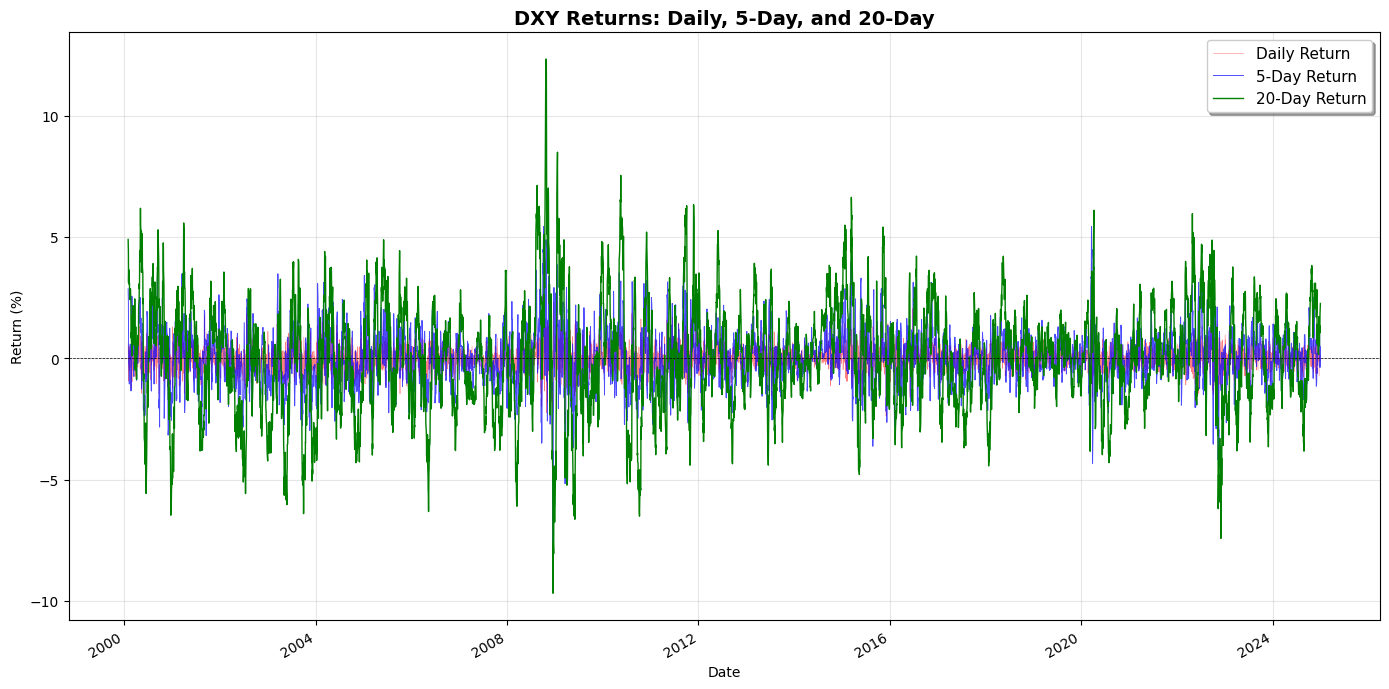

In [28]:
# Plot DXY returns at all three horizons on one graph
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(dxy_returns.index, dxy_returns['Daily_Return'] * 100, color='red', linewidth=0.4, alpha=0.5, label='Daily Return')
ax.plot(dxy_returns.index, dxy_returns['5D_Return'] * 100, color='blue', linewidth=0.7, alpha=0.7, label='5-Day Return')
ax.plot(dxy_returns.index, dxy_returns['20D_Return'] * 100, color='green', linewidth=1.0, label='20-Day Return')

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('DXY Returns: Daily, 5-Day, and 20-Day', fontsize=14, fontweight='bold')
ax.set_ylabel('Return (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [29]:
# Download GLD and GC=F, compute daily, 5-day, and 20-day returns
gold_df = pd.DataFrame()
for ticker, name in {'GLD': 'GLD', 'GC=F': 'Gold_Futures'}.items():
    df = yf.download(ticker, start='2000-01-01', end='2024-12-31')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    close = df['Close']
    gold_df[f'{name}_Daily'] = close.pct_change(periods=1)
    gold_df[f'{name}_5D'] = close.pct_change(periods=5)
    gold_df[f'{name}_20D'] = close.pct_change(periods=20)
    print(f"Downloaded {name}: {len(df)} rows")

# Drop rows with NaN (inner join + return lookback)
gold_df = gold_df.dropna(how='any')

print(f"\nFinal shape: {gold_df.shape}")
print(f"\nMissing values per column:\n{gold_df.isnull().sum()}")
print(f"\nDate range: {gold_df.index.min()} to {gold_df.index.max()}")
gold_df.head(10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded GLD: 5062 rows
Downloaded Gold_Futures: 6105 rows

Final shape: (5032, 6)

Missing values per column:
GLD_Daily             0
GLD_5D                0
GLD_20D               0
Gold_Futures_Daily    0
Gold_Futures_5D       0
Gold_Futures_20D      0
dtype: int64

Date range: 2004-12-17 00:00:00 to 2024-12-30 00:00:00


,GLD_Daily,GLD_5D,GLD_20D,Gold_Futures_Daily,Gold_Futures_5D,Gold_Futures_20D
Date,,,,,,
2004-12-17,0.011676,0.017265,-0.004281,0.010758,0.017746,-0.007194
2004-12-20,0.003394,0.009793,-0.009826,0.001812,0.007974,-0.000452
2004-12-21,-0.002706,0.015385,-0.016240,-0.001356,0.013535,-0.011191
2004-12-22,-0.004523,0.000682,-0.016313,-0.003395,-0.001134,-0.018939
2004-12-23,0.005679,0.013507,-0.017314,0.003634,0.011444,-0.013176
2004-12-27,0.004744,0.006563,-0.017885,0.007468,0.008152,-0.009125
2004-12-28,-0.002473,0.000677,-0.022687,-0.002022,0.004295,-0.020719
2004-12-29,-0.016002,-0.012664,-0.032358,-0.018681,-0.013128,-0.033902
2004-12-30,0.003894,-0.004316,-0.034156,0.003440,-0.006359,-0.036344


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


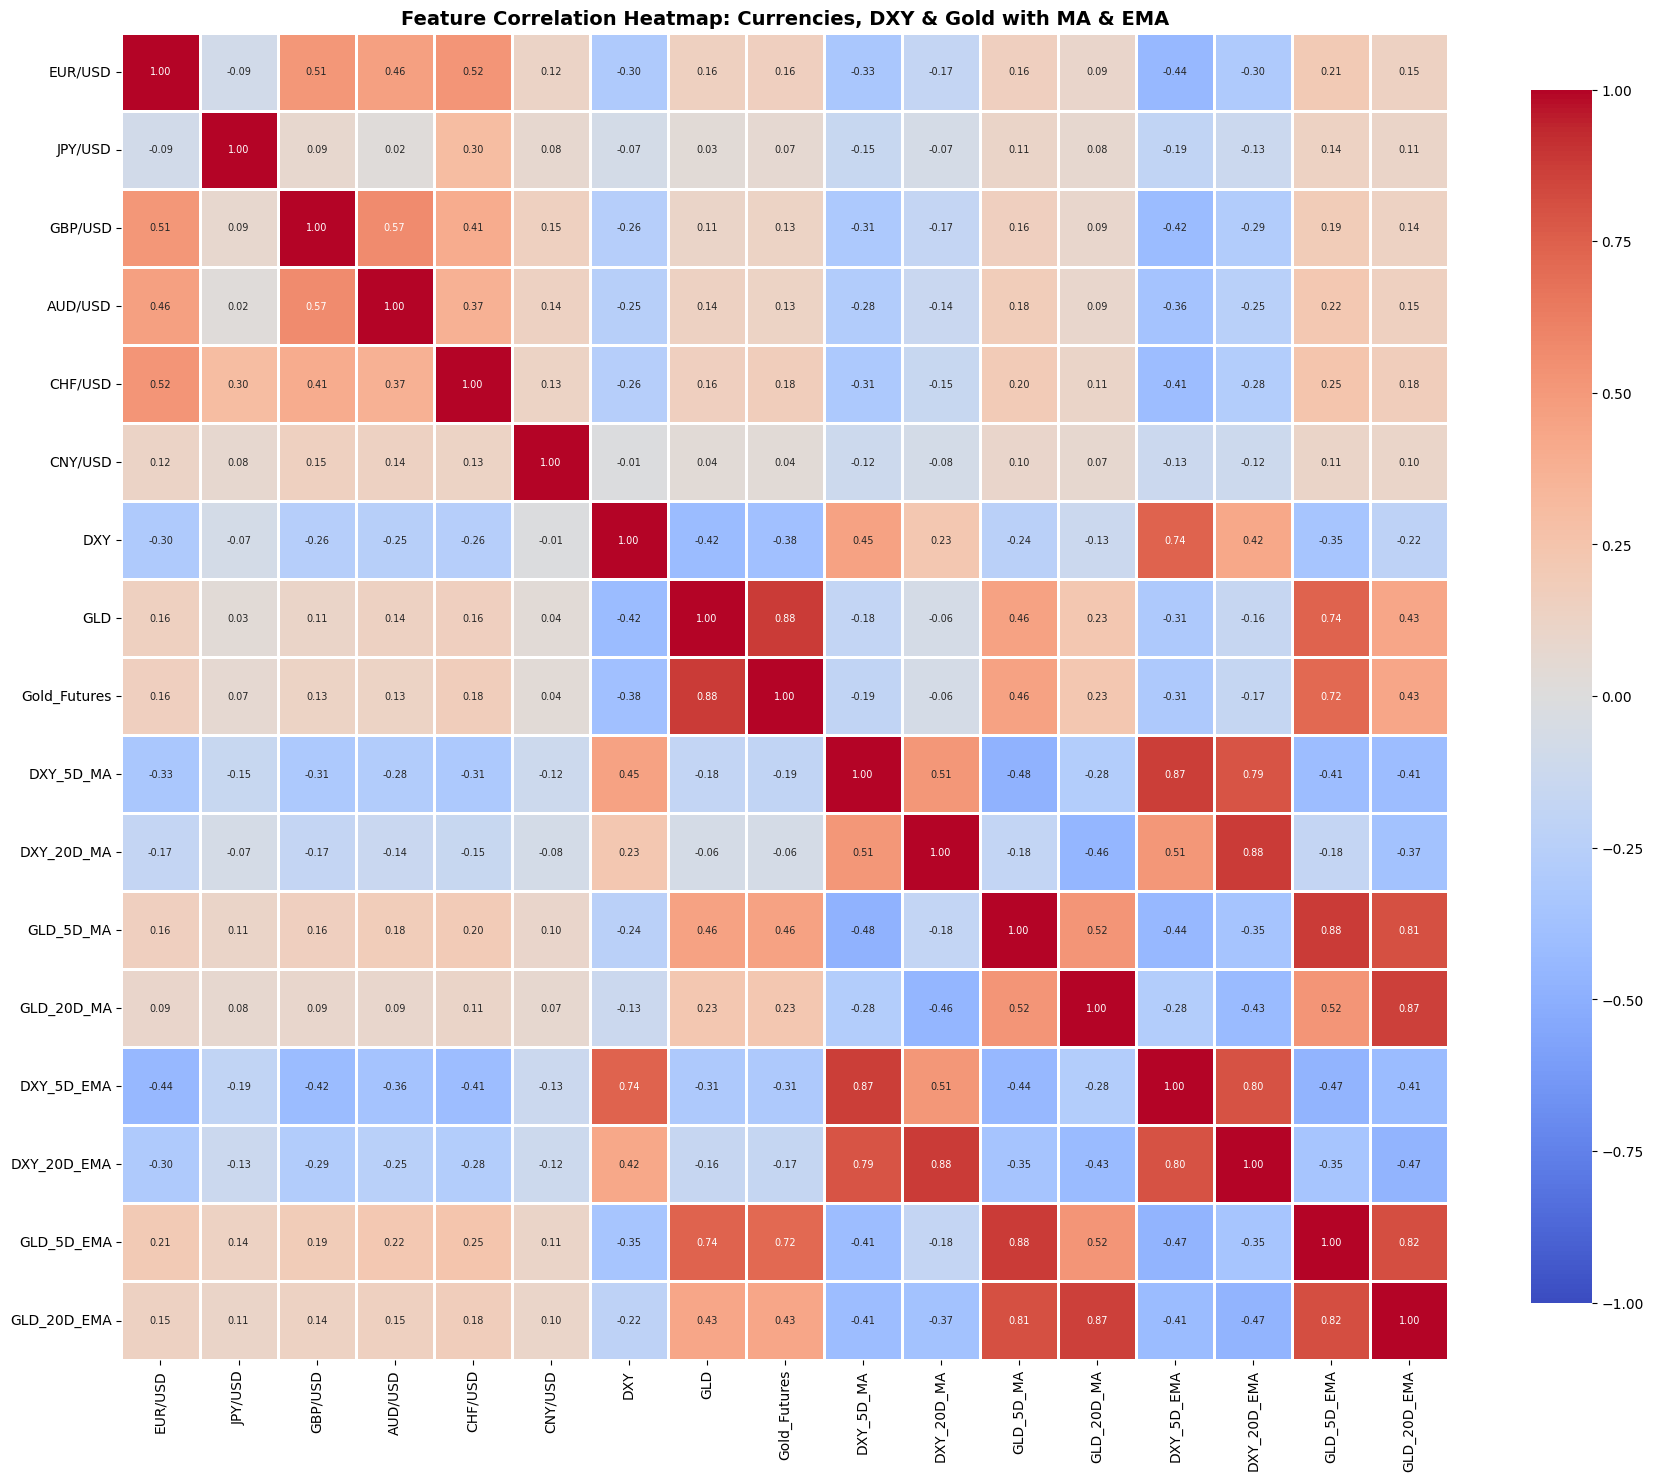

Data shape: (4574, 17)
Date range: 2006-06-13 00:00:00 to 2024-12-30 00:00:00
Missing values: 0


In [30]:
# Combine currency data, DXY close, and gold close prices into one DataFrame
combined = currency_df.copy()  # Already has DXY close + 6 currencies

# Download GLD and GC=F close prices
for ticker, name in {'GLD': 'GLD', 'GC=F': 'Gold_Futures'}.items():
    df = yf.download(ticker, start='2000-01-01', end='2024-12-31')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    combined[name] = df['Close']

# Add simple moving averages for DXY and GLD
combined['DXY_5D_MA'] = combined['DXY'].rolling(window=5).mean()
combined['DXY_20D_MA'] = combined['DXY'].rolling(window=20).mean()
combined['GLD_5D_MA'] = combined['GLD'].rolling(window=5).mean()
combined['GLD_20D_MA'] = combined['GLD'].rolling(window=20).mean()

# Add exponential moving averages for DXY and GLD
combined['DXY_5D_EMA'] = combined['DXY'].ewm(span=5, adjust=False).mean()
combined['DXY_20D_EMA'] = combined['DXY'].ewm(span=20, adjust=False).mean()
combined['GLD_5D_EMA'] = combined['GLD'].ewm(span=5, adjust=False).mean()
combined['GLD_20D_EMA'] = combined['GLD'].ewm(span=20, adjust=False).mean()

# Drop any rows with missing values
combined = combined.dropna()

# Calculate daily returns for correlation (more meaningful than raw prices)
combined_returns = combined.pct_change().dropna()

# Correlation matrix
corr = combined_returns.corr()

# Heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            fmt='.2f',
            vmin=-1, vmax=1,
            annot_kws={"size": 7})

plt.title('Feature Correlation Heatmap: Currencies, DXY & Gold with MA & EMA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Data shape: {combined.shape}")
print(f"Date range: {combined.index.min()} to {combined.index.max()}")
print(f"Missing values: {combined.isnull().sum().sum()}")

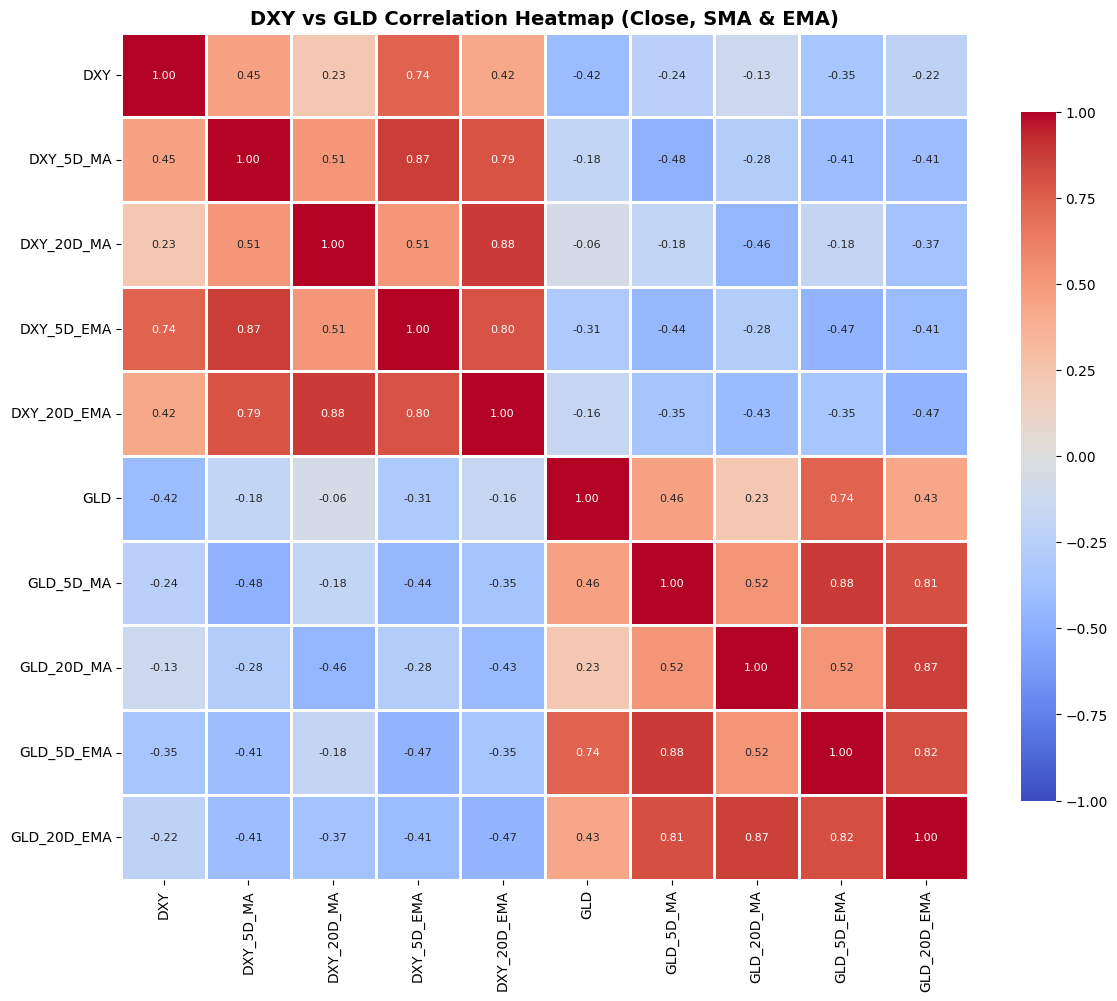

In [31]:
# Heatmap with just DXY and GLD features (close, SMA, EMA)
dxy_gld_cols = [
    'DXY', 'DXY_5D_MA', 'DXY_20D_MA', 'DXY_5D_EMA', 'DXY_20D_EMA',
    'GLD', 'GLD_5D_MA', 'GLD_20D_MA', 'GLD_5D_EMA', 'GLD_20D_EMA',
]
dxy_gld_returns = combined[dxy_gld_cols].pct_change().dropna()
corr_dxy_gld = dxy_gld_returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_dxy_gld,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            fmt='.2f',
            vmin=-1, vmax=1,
            annot_kws={"size": 8})

plt.title('DXY vs GLD Correlation Heatmap (Close, SMA & EMA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# DXY & GLD data table (close, SMA, EMA)
dxy_gld_data = combined[['DXY', 'DXY_5D_MA', 'DXY_20D_MA', 'DXY_5D_EMA', 'DXY_20D_EMA',
                          'GLD', 'GLD_5D_MA', 'GLD_20D_MA', 'GLD_5D_EMA', 'GLD_20D_EMA']]

print(f"Shape: {dxy_gld_data.shape}")
print(f"Missing values: {dxy_gld_data.isnull().sum().sum()}\n")
dxy_gld_data.head(10)

Shape: (4574, 10)
Missing values: 0



,DXY,DXY_5D_MA,DXY_20D_MA,DXY_5D_EMA,DXY_20D_EMA,GLD,GLD_5D_MA,GLD_20D_MA,GLD_5D_EMA,GLD_20D_EMA
Date,,,,,,,,,,
2006-06-13,86.430000,85.780000,84.8790,85.794712,85.009420,55.919998,59.917999,63.8085,59.390418,63.109611
2006-06-14,86.139999,86.010001,84.9775,85.909808,85.117095,55.619999,58.585999,63.1590,58.133611,62.396315
2006-06-15,86.019997,86.031999,85.0360,85.946538,85.203085,57.320000,57.867999,62.6175,57.862408,61.912856
2006-06-16,85.919998,86.071999,85.1065,85.937691,85.271363,57.680000,57.313999,62.1285,57.801605,61.509727
2006-06-19,86.309998,86.163998,85.1780,86.061793,85.370280,56.360001,56.580000,61.6675,57.321070,61.019277
2006-06-20,86.180000,86.113998,85.2695,86.101196,85.447397,57.299999,56.856000,61.2675,57.314047,60.665060
2006-06-21,85.779999,86.041998,85.3410,85.994130,85.479073,58.330002,57.398000,60.8650,57.652698,60.442674
2006-06-22,86.389999,86.115999,85.4130,86.126086,85.565828,57.730000,57.480000,60.5485,57.678465,60.184324
2006-06-23,86.820000,86.295999,85.5215,86.357391,85.685273,57.990002,57.542001,60.2130,57.782311,59.975341


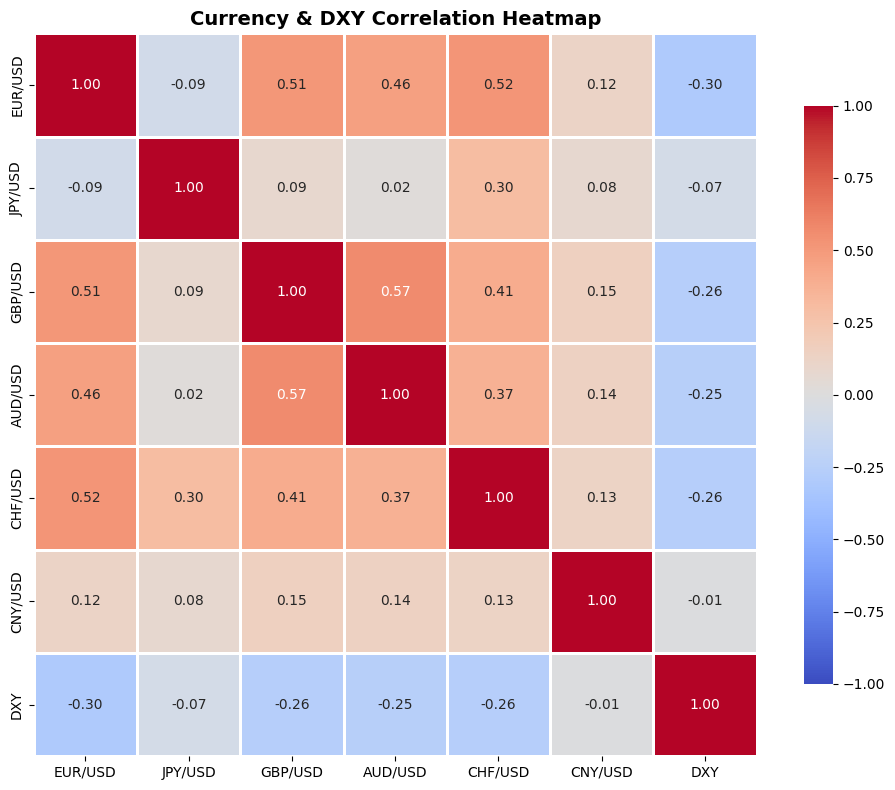

In [33]:
# Heatmap with just currency data and DXY raw value
curr_dxy_cols = ['EUR/USD', 'JPY/USD', 'GBP/USD', 'AUD/USD', 'CHF/USD', 'CNY/USD', 'DXY']
curr_dxy_returns = combined[curr_dxy_cols].pct_change().dropna()
corr_curr_dxy = curr_dxy_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_curr_dxy,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            fmt='.2f',
            vmin=-1, vmax=1)

plt.title('Currency & DXY Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SIMPLE LINEAR REGRESSION
GLD_20D_MA_change = β₀ + β₁ * DXY_20D_MA_change
  β₀ (intercept) = 0.000348
  β₁ (DXY_20D_MA) = -1.000662
  R² = 0.2116
  RMSE = 0.002267


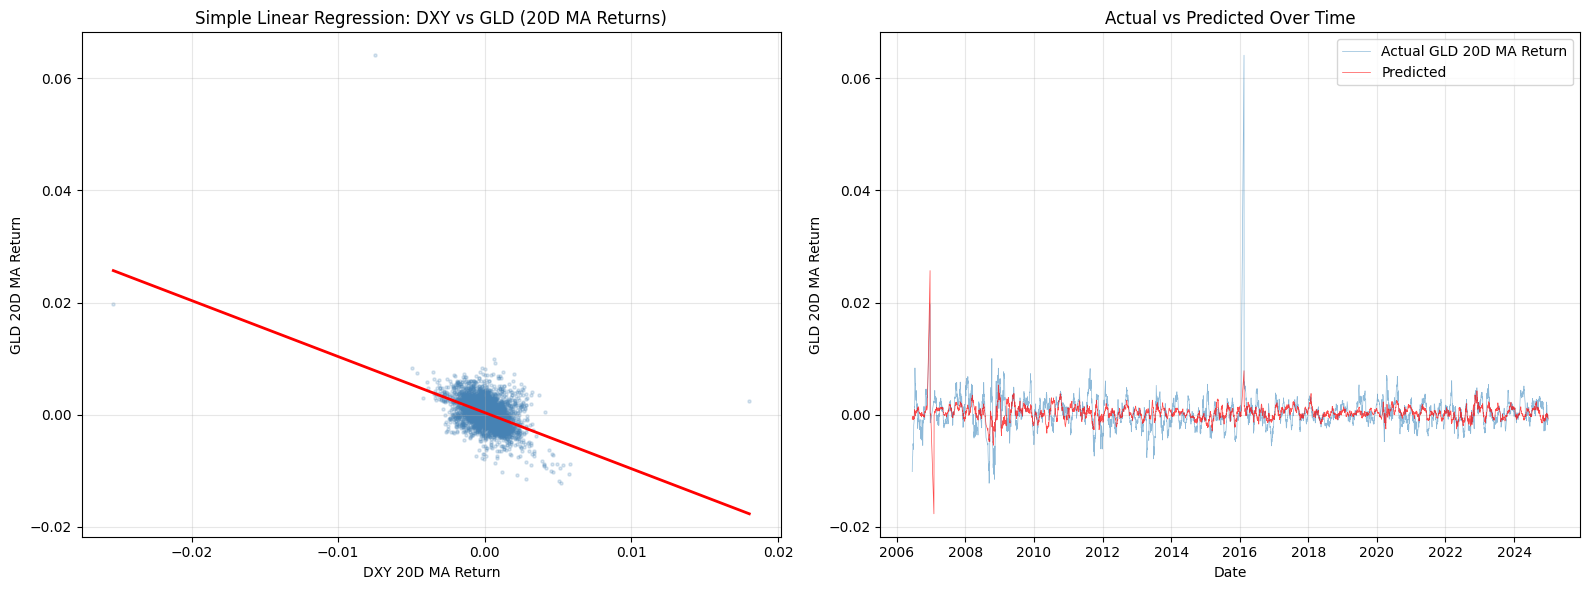

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- Simple Linear Regression ---
# Predict GLD 20D MA % change from DXY 20D MA % change

reg_df = combined[['DXY_20D_MA', 'GLD_20D_MA']].pct_change().dropna()
reg_df.columns = ['DXY_20D_MA_ret', 'GLD_20D_MA_ret']

X_simple = reg_df[['DXY_20D_MA_ret']]
y = reg_df['GLD_20D_MA_ret']

model_simple = LinearRegression()
model_simple.fit(X_simple, y)
y_pred_simple = model_simple.predict(X_simple)

print("=" * 60)
print("SIMPLE LINEAR REGRESSION")
print("GLD_20D_MA_change = β₀ + β₁ * DXY_20D_MA_change")
print("=" * 60)
print(f"  β₀ (intercept) = {model_simple.intercept_:.6f}")
print(f"  β₁ (DXY_20D_MA) = {model_simple.coef_[0]:.6f}")
print(f"  R² = {r2_score(y, y_pred_simple):.4f}")
print(f"  RMSE = {mean_squared_error(y, y_pred_simple)**0.5:.6f}")

# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_simple, y, alpha=0.2, s=5, color='steelblue')
axes[0].plot(X_simple.sort_values('DXY_20D_MA_ret'), 
             model_simple.predict(X_simple.sort_values('DXY_20D_MA_ret')), 
             color='red', linewidth=2)
axes[0].set_xlabel('DXY 20D MA Return')
axes[0].set_ylabel('GLD 20D MA Return')
axes[0].set_title('Simple Linear Regression: DXY vs GLD (20D MA Returns)')
axes[0].grid(alpha=0.3)

axes[1].plot(reg_df.index, y, alpha=0.5, linewidth=0.5, label='Actual GLD 20D MA Return')
axes[1].plot(reg_df.index, y_pred_simple, alpha=0.7, linewidth=0.5, label='Predicted', color='red')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('GLD 20D MA Return')
axes[1].set_title('Actual vs Predicted Over Time')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

MULTIPLE LINEAR REGRESSION
GLD_20D_MA_ret = β₀ + β₁*DXY_20D_MA + β₂*CHF_20D_MA + β₃*AUD_20D_MA
  β₀ (intercept) = 0.000331
  β  (DXY_20D_ret    ) = -0.630183
  β  (CHF_20D_ret    ) = +0.243180
  β  (AUD_20D_ret    ) = +0.182466
  R² = 0.2334
  RMSE = 0.002215

  R² improvement over simple model: 0.0218


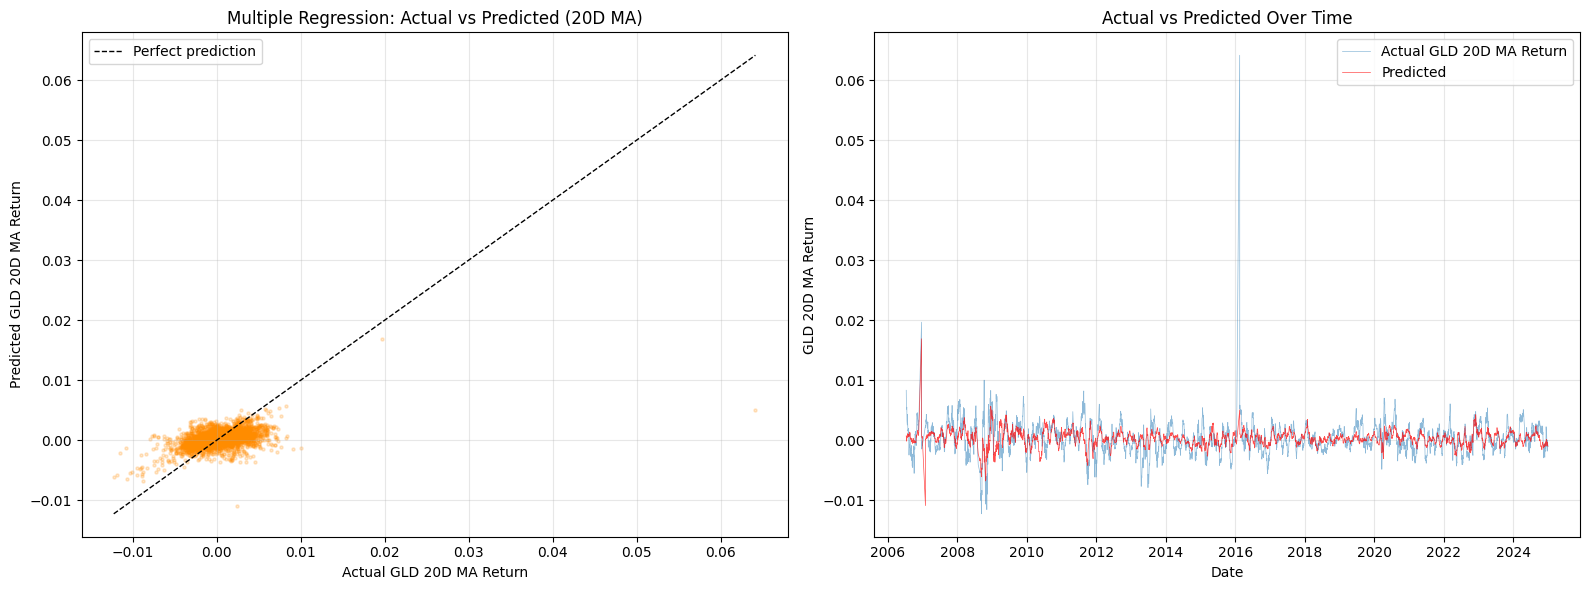

In [35]:
# --- Multiple Linear Regression ---
# Predict GLD 20D MA return from DXY 20D MA + CHF/USD 20D MA + AUD/USD 20D MA

# Compute 20D MAs for CHF/USD and AUD/USD
combined['CHF_20D_MA'] = combined['CHF/USD'].rolling(window=20).mean()
combined['AUD_20D_MA'] = combined['AUD/USD'].rolling(window=20).mean()

multi_df = combined[['DXY_20D_MA', 'CHF_20D_MA', 'AUD_20D_MA', 'GLD_20D_MA']].pct_change().dropna()
multi_df.columns = ['DXY_20D_ret', 'CHF_20D_ret', 'AUD_20D_ret', 'GLD_20D_ret']

X_multi = multi_df[['DXY_20D_ret', 'CHF_20D_ret', 'AUD_20D_ret']]
y_multi = multi_df['GLD_20D_ret']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)
y_pred_multi = model_multi.predict(X_multi)

print("=" * 60)
print("MULTIPLE LINEAR REGRESSION")
print("GLD_20D_MA_ret = β₀ + β₁*DXY_20D_MA + β₂*CHF_20D_MA + β₃*AUD_20D_MA")
print("=" * 60)
print(f"  β₀ (intercept) = {model_multi.intercept_:.6f}")
for name, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"  β  ({name:15s}) = {coef:+.6f}")
print(f"  R² = {r2_score(y_multi, y_pred_multi):.4f}")
print(f"  RMSE = {mean_squared_error(y_multi, y_pred_multi)**0.5:.6f}")

# Compare R² to simple model
print(f"\n  R² improvement over simple model: "
      f"{r2_score(y_multi, y_pred_multi) - r2_score(y, y_pred_simple):.4f}")

# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_multi, y_pred_multi, alpha=0.2, s=5, color='darkorange')
axes[0].plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], 
             'k--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual GLD 20D MA Return')
axes[0].set_ylabel('Predicted GLD 20D MA Return')
axes[0].set_title('Multiple Regression: Actual vs Predicted (20D MA)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(multi_df.index, y_multi, alpha=0.5, linewidth=0.5, label='Actual GLD 20D MA Return')
axes[1].plot(multi_df.index, y_pred_multi, alpha=0.7, linewidth=0.5, label='Predicted', color='red')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('GLD 20D MA Return')
axes[1].set_title('Actual vs Predicted Over Time')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

LAG-BASED REGRESSION (20D MA)
GLD_20D_MA_ret_today = β₀ + β₁*DXY_20D_MA_t-1 + β₂*DXY_20D_MA_t-5
                          + β₃*DXY_20D_MA_t-10 + β₄*DXY_20D_MA_t-20
  β₀ (intercept)       = 0.000347
  β  (DXY_20D_MA_ret_lag1      ) = -0.682209
  β  (DXY_20D_MA_ret_lag5      ) = -0.134139
  β  (DXY_20D_MA_ret_lag10     ) = -0.024388
  β  (DXY_20D_MA_ret_lag20     ) = +0.083885
  R² = 0.1343
  RMSE = 0.002351

  Individual lag R² scores:
    DXY_20D_MA_ret_lag1       alone: R² = 0.1313
    DXY_20D_MA_ret_lag5       alone: R² = 0.0754
    DXY_20D_MA_ret_lag10      alone: R² = 0.0315
    DXY_20D_MA_ret_lag20      alone: R² = 0.0000


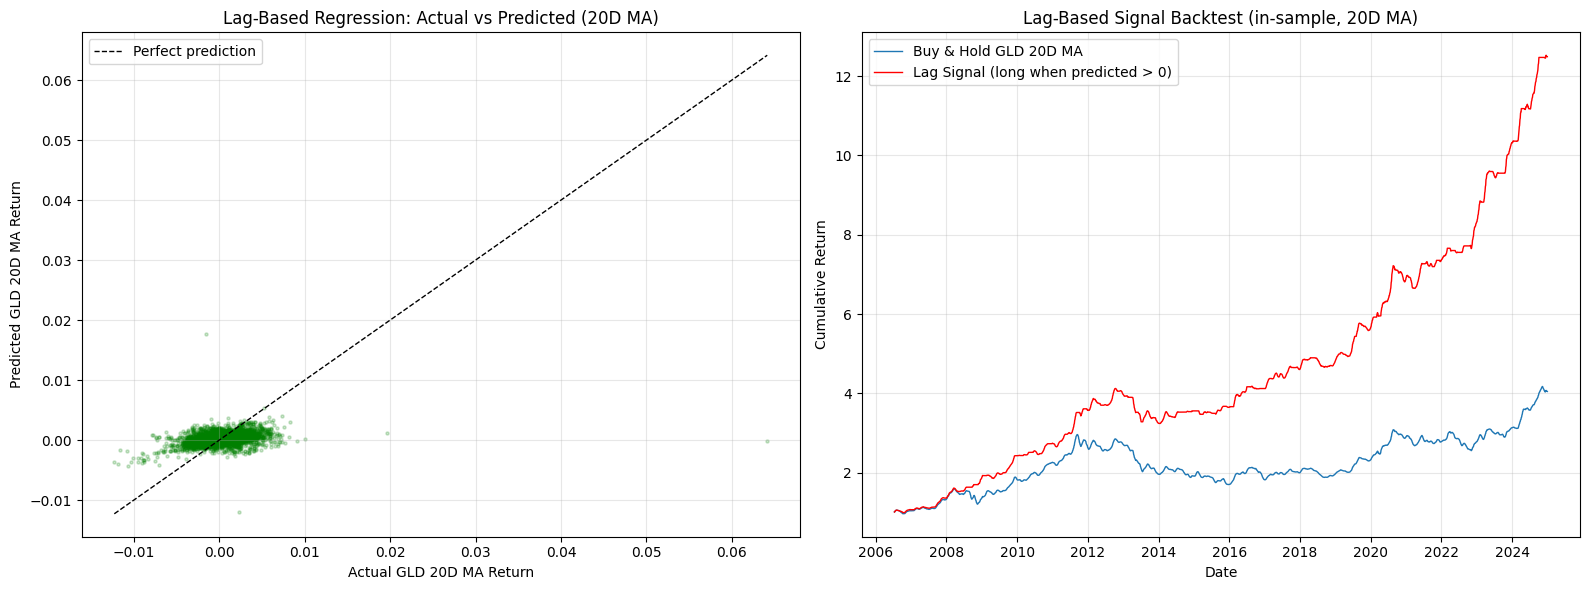


Backtest (in-sample, no transaction costs):
  Buy & Hold GLD 20D MA total return:  304.8%
  Lag signal total return:              1149.1%
  Days in market:                       3043 / 4553 (66.8%)


In [36]:
# --- Lag-Based Regression ---
# Can last week's / last month's DXY 20D MA move predict today's GLD 20D MA move?

lag_df = pd.DataFrame()
lag_df['GLD_20D_MA_ret'] = combined['GLD_20D_MA'].pct_change()
lag_df['DXY_20D_MA_ret_lag1'] = combined['DXY_20D_MA'].pct_change().shift(1)    # yesterday
lag_df['DXY_20D_MA_ret_lag5'] = combined['DXY_20D_MA'].pct_change().shift(5)    # 1 week ago
lag_df['DXY_20D_MA_ret_lag10'] = combined['DXY_20D_MA'].pct_change().shift(10)  # 2 weeks ago
lag_df['DXY_20D_MA_ret_lag20'] = combined['DXY_20D_MA'].pct_change().shift(20)  # 1 month ago
lag_df = lag_df.dropna()

X_lag = lag_df[['DXY_20D_MA_ret_lag1', 'DXY_20D_MA_ret_lag5', 
                'DXY_20D_MA_ret_lag10', 'DXY_20D_MA_ret_lag20']]
y_lag = lag_df['GLD_20D_MA_ret']

model_lag = LinearRegression()
model_lag.fit(X_lag, y_lag)
y_pred_lag = model_lag.predict(X_lag)

print("=" * 60)
print("LAG-BASED REGRESSION (20D MA)")
print("GLD_20D_MA_ret_today = β₀ + β₁*DXY_20D_MA_t-1 + β₂*DXY_20D_MA_t-5")
print("                          + β₃*DXY_20D_MA_t-10 + β₄*DXY_20D_MA_t-20")
print("=" * 60)
print(f"  β₀ (intercept)       = {model_lag.intercept_:.6f}")
for name, coef in zip(X_lag.columns, model_lag.coef_):
    print(f"  β  ({name:25s}) = {coef:+.6f}")
print(f"  R² = {r2_score(y_lag, y_pred_lag):.4f}")
print(f"  RMSE = {mean_squared_error(y_lag, y_pred_lag)**0.5:.6f}")

# Check which lags matter most
print(f"\n  Individual lag R² scores:")
for col in X_lag.columns:
    m = LinearRegression().fit(lag_df[[col]], y_lag)
    r2 = r2_score(y_lag, m.predict(lag_df[[col]]))
    print(f"    {col:25s} alone: R² = {r2:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_lag, y_pred_lag, alpha=0.2, s=5, color='green')
axes[0].plot([y_lag.min(), y_lag.max()], [y_lag.min(), y_lag.max()],
             'k--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual GLD 20D MA Return')
axes[0].set_ylabel('Predicted GLD 20D MA Return')
axes[0].set_title('Lag-Based Regression: Actual vs Predicted (20D MA)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative returns: actual vs predicted signal
cum_actual = (1 + y_lag).cumprod()
# Strategy: go long gold when model predicts positive return
signal = (y_pred_lag > 0).astype(int)
strategy_ret = y_lag * signal
cum_strategy = (1 + strategy_ret).cumprod()

axes[1].plot(lag_df.index, cum_actual, label='Buy & Hold GLD 20D MA', linewidth=1)
axes[1].plot(lag_df.index, cum_strategy, label='Lag Signal (long when predicted > 0)', linewidth=1, color='red')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return')
axes[1].set_title('Lag-Based Signal Backtest (in-sample, 20D MA)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBacktest (in-sample, no transaction costs):")
print(f"  Buy & Hold GLD 20D MA total return:  {(cum_actual.iloc[-1]-1)*100:.1f}%")
print(f"  Lag signal total return:              {(cum_strategy.iloc[-1]-1)*100:.1f}%")
print(f"  Days in market:                       {signal.sum()} / {len(signal)} ({signal.mean()*100:.1f}%)")